# 1. 파일 불러오기

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import glob
import os

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

base_path = "/mnt/data"

# 2. 교통사고 데이터 확인

In [ ]:
acc_path = os.path.join(base_path, "/content/drive/MyDrive/노인 보행자 사고 데이터셋/사고분석 -지역별.xlsx")

acc = pd.read_excel(acc_path)
acc.head()
acc.info()
acc["시군구"].value_counts().head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5782 entries, 0 to 5781
Data columns (total 22 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   구분번호        5782 non-null   int64 
 1   발생년월        5782 non-null   object
 2   주야          5782 non-null   object
 3   시군구         5782 non-null   object
 4   사고내용        5782 non-null   object
 5   사망자수        5782 non-null   int64 
 6   중상자수        5782 non-null   int64 
 7   경상자수        5782 non-null   int64 
 8   부상신고자수      5782 non-null   int64 
 9   사고유형        5782 non-null   object
 10  법규위반        5782 non-null   object
 11  노면상태        5782 non-null   object
 12  기상상태        5782 non-null   object
 13  도로형태        5782 non-null   object
 14  가해운전자 차종    5782 non-null   object
 15  가해운전자 성별    5782 non-null   object
 16  가해운전자 연령대   5782 non-null   object
 17  가해운전자 상해정도  5782 non-null   object
 18  피해운전자 차종    5782 non-null   object
 19  피해운전자 성별    5782 non-null   object
 20  피해운전자 연령

,count
시군구,
서울특별시 동대문구,423
서울특별시 송파구,339
서울특별시 중랑구,315
서울특별시 은평구,301
서울특별시 강서구,284


In [ ]:
# 노인 보행자 사고만 남기는 코드

acc_elder = acc[
    (acc["피해운전자 차종"] == "보행자") &
    (acc["피해운전자 연령대"] == "65세 이상")
].copy()

acc_elder.shape

(5673, 22)

In [ ]:
# 자치구명 추출

acc_elder["자치구"] = acc_elder["시군구"].str.extract(r"서울특별시\s+(\S+구)")

acc_elder[["시군구", "자치구"]].drop_duplicates().head()

,시군구,자치구
0,서울특별시 도봉구,도봉구
1,서울특별시 서대문구,서대문구
2,서울특별시 영등포구,영등포구
3,서울특별시 강서구,강서구
5,서울특별시 구로구,구로구


In [ ]:
# 자치구별 사고 집계

acc_gu = (
    acc_elder
    .groupby("자치구")
    .agg(
        사고발생건수=("구분번호", "count"),
        사망자수=("사망자수", "sum"),
        중상자수=("중상자수", "sum"),
        경상자수=("경상자수", "sum"),
        부상신고자수=("부상신고자수", "sum")
    )
    .reset_index()
)

acc_gu.head()

,자치구,사고발생건수,사망자수,중상자수,경상자수,부상신고자수
0,강남구,270,6,133,111,26
1,강동구,264,2,131,120,16
2,강북구,271,10,134,136,11
3,강서구,275,11,129,114,30
4,관악구,230,12,108,110,7


# 3. 생활인구 데이터 만들기

In [ ]:
# 자치구 코드 매핑 만들기

gu_code_map = {
    11110: "종로구",
    11140: "중구",
    11170: "용산구",
    11200: "성동구",
    11215: "광진구",
    11230: "동대문구",
    11260: "중랑구",
    11290: "성북구",
    11305: "강북구",
    11320: "도봉구",
    11350: "노원구",
    11380: "은평구",
    11410: "서대문구",
    11440: "마포구",
    11470: "양천구",
    11500: "강서구",
    11530: "구로구",
    11545: "금천구",
    11560: "영등포구",
    11590: "동작구",
    11620: "관악구",
    11650: "서초구",
    11680: "강남구",
    11710: "송파구",
    11740: "강동구"
}

In [ ]:
# 2022/2023 생활인구 처리 함수

def load_living_kor(path):
    df = pd.read_csv(path, encoding="cp949")

    df["기준일ID"] = pd.to_datetime(df["기준일ID"].astype(str), format="%Y%m%d")
    df["요일"] = df["기준일ID"].dt.dayofweek
    df["주중여부"] = np.where(df["요일"] < 5, "주중", "주말")

    elderly_cols = [
        "남자65세부터69세생활인구수",
        "남자70세이상생활인구수",
        "여자65세부터69세생활인구수",
        "여자70세이상생활인구수"
    ]

    df["노인생활인구수"] = df[elderly_cols].sum(axis=1)
    df["자치구"] = df["자치구코드"].map(gu_code_map)

    return df[["기준일ID", "시간대구분", "자치구코드", "자치구", "주중여부", "노인생활인구수"]]

In [ ]:
# 2024 생활인구 처리 함수

def load_living_eng(path):
    df = pd.read_csv(path, encoding="utf-8")

    df["stdr_de_id"] = pd.to_datetime(df["stdr_de_id"].astype(str), format="%Y%m%d")
    df["요일"] = df["stdr_de_id"].dt.dayofweek
    df["주중여부"] = np.where(df["요일"] < 5, "주중", "주말")

    elderly_cols = [
        "male_f65t69_lvpop_co",
        "male_f70t74_lvpop_co",
        "female_f65t69_lvpop_co",
        "female_f70t74_lvpop_co"
    ]

    df["노인생활인구수"] = df[elderly_cols].sum(axis=1)
    df["자치구"] = df["adstrd_code_se"].map(gu_code_map)

    return df.rename(columns={
        "stdr_de_id": "기준일ID",
        "tmzon_pd_se": "시간대구분",
        "adstrd_code_se": "자치구코드"
    })[["기준일ID", "시간대구분", "자치구코드", "자치구", "주중여부", "노인생활인구수"]]

In [ ]:
# 주의: 2024 파일은 70세 이상이 아니라 70~74세까지만 있는 구조로 보였음. 75세 이상 컬럼이 없는지 한 번 확인해야 함.

living_2024_raw = pd.read_csv(os.path.join(base_path, "/content/drive/MyDrive/노인 보행자 사고 데이터셋/LOCAL_PEOPLE_GU_2024.csv"), nrows=5)
[col for col in living_2024_raw.columns if "70" in col or "75" in col or "80" in col]

['male_f70t74_lvpop_co', 'female_f70t74_lvpop_co']

# 3-1. 생활인구 파일 합치기

In [ ]:
living_2022 = load_living_kor(os.path.join(base_path, "/content/drive/MyDrive/노인 보행자 사고 데이터셋/LOCAL_PEOPLE_GU_2022.csv"))
living_2023 = load_living_kor(os.path.join(base_path, "/content/drive/MyDrive/노인 보행자 사고 데이터셋/LOCAL_PEOPLE_GU_2023.csv"))
living_2024 = load_living_eng(os.path.join(base_path, "/content/drive/MyDrive/노인 보행자 사고 데이터셋/LOCAL_PEOPLE_GU_2024.csv"))

living = pd.concat([living_2022, living_2023, living_2024], ignore_index=True)

living.head()

,기준일ID,시간대구분,자치구코드,자치구,주중여부,노인생활인구수
0,2022-01-01,0,11110,종로구,주말,33553.7534
1,2022-01-01,0,11140,중구,주말,23576.4980
2,2022-01-01,0,11170,용산구,주말,36473.2914
3,2022-01-01,0,11200,성동구,주말,46832.2662
4,2022-01-01,0,11215,광진구,주말,47807.0919


In [ ]:
# 낮 시간대만 추출
# 노인 보행자 사고 위험은 심야보다 낮 시간대 유동인구가 핵심이니까 일단 9시~17시로 잡음.

day_living = living[
    living["시간대구분"].between(9, 17)
].copy()

In [ ]:
# 자치구별 주중/주말 평균 노인 생활인구

living_gu = (
    day_living
    .groupby(["자치구", "주중여부"])
    .agg(노인생활인구_낮평균=("노인생활인구수", "mean"))
    .reset_index()
)

living_gu = living_gu.pivot(
    index="자치구",
    columns="주중여부",
    values="노인생활인구_낮평균"
).reset_index()

living_gu.columns.name = None
living_gu = living_gu.rename(columns={
    "주중": "노인생활인구_주중낮",
    "주말": "노인생활인구_주말낮"
})

living_gu["노인생활인구_낮평균"] = living_gu[
    ["노인생활인구_주중낮", "노인생활인구_주말낮"]
].mean(axis=1)

living_gu.head()

,자치구,노인생활인구_주말낮,노인생활인구_주중낮,노인생활인구_낮평균
0,강남구,88135.850900,104150.291929,96143.071414
1,강동구,81992.858954,81935.335205,81964.097079
2,강북구,55458.689670,53691.807732,54575.248701
3,강서구,79909.864280,79761.648551,79835.756415
4,관악구,63384.096673,61238.851398,62311.474036


# 4. 등록인구 즉, 거주 노인 인구 만들기

In [ ]:
import pandas as pd
import numpy as np
import os

pop_path = os.path.join(base_path, "/content/drive/MyDrive/노인 보행자 사고 데이터셋/서울시 등록인구(연령별:동별) 통계.xlsx")

# 원본 구조 그대로 읽기
pop_raw = pd.read_excel(pop_path, sheet_name="데이터", header=None)

# 0행: 기간, 1행: 연령대
period_row = pop_raw.iloc[0]
age_row = pop_raw.iloc[1]

# 실제 데이터는 2행부터
pop_data = pop_raw.iloc[2:].copy()

# 앞의 두 컬럼명 정리
pop_data = pop_data.rename(columns={
    0: "자치구",
    1: "항목"
})

# 자치구명이 NaN인 행은 위 행의 자치구명을 따라가므로 forward fill
pop_data["자치구"] = pop_data["자치구"].ffill()

# 숫자 컬럼의 '-' 처리
for col in pop_data.columns:
    if col not in ["자치구", "항목"]:
        pop_data[col] = pd.to_numeric(pop_data[col].replace("-", np.nan), errors="coerce").fillna(0)

# 사용할 기준 시점
target_period = "2026 1/4"

# 65세 이상 연령대
elderly_ages = [
    "65~69세",
    "70~74세",
    "75~79세",
    "80~84세",
    "85~89세",
    "90~94세",
    "95~99세",
    "100세 이상"
]

# 2026 1/4 중 65세 이상 컬럼 번호 찾기
elderly_cols = [
    col for col in pop_data.columns
    if col not in ["자치구", "항목"]
    and period_row[col] == target_period
    and age_row[col] in elderly_ages
]

print("65세 이상 컬럼:", elderly_cols)
print("연령대:", [age_row[col] for col in elderly_cols])

65세 이상 컬럼: [38, 39, 40, 41, 42, 43, 44, 45]
연령대: ['65~69세', '70~74세', '75~79세', '80~84세', '85~89세', '90~94세', '95~99세', '100세 이상']


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/tmp/ipykernel_10163/2797998327.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  pop_data[col] = pd.to_numeric(pop_data[col].replace("-", np.nan), errors="coerce").fillna(0)


In [ ]:
# 이제 자치구별 노인 거주인구를 만들면 됨.

# 자치구 단위 + 전체 인구 '계'만 사용
pop_gu = pop_data[
    (pop_data["항목"] == "계") &
    (pop_data["자치구"].astype(str).str.endswith("구"))
].copy()

pop_gu["노인거주인구"] = pop_gu[elderly_cols].sum(axis=1)

pop_gu = pop_gu[["자치구", "노인거주인구"]].reset_index(drop=True)

pop_gu.head(30)

,자치구,노인거주인구
0,종로구,31347.0
1,중구,27996.0
2,용산구,40820.0
3,성동구,54244.0
4,광진구,63755.0
5,동대문구,74076.0
6,중랑구,89759.0
7,성북구,88669.0
8,강북구,75413.0
9,도봉구,79529.0


In [ ]:
# 확인용
pop_gu.shape, pop_gu["자치구"].nunique()

((25, 2), 25)

# 5. 노인보호구역 데이터

In [ ]:
# 보호구역 파일은 2022.3 기준 170개소에서 2024.12 기준 195개소까지 증가하는 형태.
# 2024.12 기준 파일에는 노인보호구역 195개소라고 되어 있음.
# 다만 이 파일이 HWPX라서 파이썬에서 바로 표로 읽기가 조금 까다로움.
# 1차 EDA에서는 자치구별 개수만 필요하니까, 가장 쉬운 방법은 HWPX를 엑셀 또는 CSV로 저장해서 다시 올리는 것.
# 그래서 이 파일은 엑셀로 변환함.

In [ ]:
import pandas as pd
import numpy as np
import os

base_path = "/mnt/data"

zone_path = os.path.join(
    base_path,
    "/content/drive/MyDrive/노인 보행자 사고 데이터셋/노인_장애인보호구역_지정현황_2024_12월.xlsx"
)

In [ ]:
# 시트와 구조를 확인

xls = pd.ExcelFile(zone_path)
xls.sheet_names

['노인 보호구역', '장애인 보호구역']

In [ ]:
zone_raw = pd.read_excel(zone_path, sheet_name=0, header=None)
zone_raw.head(20)

,0,1,2,3,4
0,노인 보호구역 지정현황 (2024년 12월 기준),NaN,NaN,NaN,NaN
1,연번,자치구,시설명,위치,지정연도
2,1,종로구,종로노인종합복지관,율곡로19길 17-8,2009
3,2,종로구,종로노인종합복지관 무악센터,통일로14길 30,2016
4,3,종로구,서울노인복지센터,삼일대로 467,2016
5,4,종로구,락희거리,삼일대로 428,2017
6,5,종로구,종묘광장공원 동순라길,동순라길,2018
7,6,종로구,운니경로당,삼일대로32길 51,2019
8,7,중구,신당6동 노인복지관(동화동경로당),퇴계로80길 52,2008
9,8,중구,신일경로당,청구로 121,2017


In [ ]:
# 노인보호구역 표만 자동 추출
# 엑셀 변환 파일은 헤더 위치가 일정하지 않을 수 있어서, 아래처럼 자동으로 연번, 자치구, 시설명, 위치가 있는 행을 찾아서 읽는 방식으로

def load_elderly_protection_zone(path, sheet_name=0):
    raw = pd.read_excel(path, sheet_name=sheet_name, header=None)

    # 1) 헤더 행 찾기: '자치구', '시설명', '위치'가 들어간 행
    header_idx = None
    for i in range(len(raw)):
        row_text = " ".join(raw.iloc[i].dropna().astype(str).tolist())
        if ("자치구" in row_text) and ("시설명" in row_text) and ("위치" in row_text):
            header_idx = i
            break

    if header_idx is None:
        raise ValueError("헤더 행을 찾지 못했습니다. zone_raw.head(30)을 확인해 주세요.")

    # 2) 헤더 적용
    df = raw.iloc[header_idx + 1:].copy()
    df.columns = raw.iloc[header_idx].astype(str).str.strip()

    # 3) 빈 컬럼 제거
    df = df.loc[:, ~df.columns.str.contains("^nan$", case=False)]

    # 4) 컬럼명 표준화
    df.columns = (
        df.columns
        .astype(str)
        .str.replace("\n", "", regex=False)
        .str.replace(" ", "", regex=False)
        .str.strip()
    )

    # 5) 장애인보호구역 섹션이 같이 들어있으면 그 전까지만 사용
    #    즉, '장애인'이라는 문구가 처음 나오는 행 이전까지만 자름
    row_texts = df.astype(str).agg(" ".join, axis=1)
    disability_rows = row_texts[row_texts.str.contains("장애인", na=False)].index

    if len(disability_rows) > 0:
        first_disability_idx = disability_rows[0]
        df = df.loc[:first_disability_idx - 1].copy()

    # 6) 자치구 컬럼 찾기
    gu_col_candidates = [c for c in df.columns if "자치구" in c]
    if len(gu_col_candidates) == 0:
        raise ValueError(f"자치구 컬럼을 찾지 못했습니다. 현재 컬럼: {df.columns.tolist()}")
    gu_col = gu_col_candidates[0]

    # 7) 자치구 값이 정상인 행만 남김
    df[gu_col] = df[gu_col].astype(str).str.strip()
    df = df[df[gu_col].str.endswith("구", na=False)].copy()

    # 8) 컬럼명 통일
    df = df.rename(columns={gu_col: "자치구"})

    return df

In [ ]:
zone = load_elderly_protection_zone(zone_path)

zone.head()

1,연번,자치구,시설명,위치,지정연도
2,1,종로구,종로노인종합복지관,율곡로19길 17-8,2009
3,2,종로구,종로노인종합복지관 무악센터,통일로14길 30,2016
4,3,종로구,서울노인복지센터,삼일대로 467,2016
5,4,종로구,락희거리,삼일대로 428,2017
6,5,종로구,종묘광장공원 동순라길,동순라길,2018


In [ ]:
zone.shape

(195, 5)

In [ ]:
# 자치구별 노인보호구역 수 만들기

zone_gu = (
    zone
    .groupby("자치구")
    .size()
    .reset_index(name="노인보호구역수")
    .sort_values("노인보호구역수", ascending=False)
)

zone_gu.head(10)

,자치구,노인보호구역수
17,송파구,24
14,서초구,14
0,강남구,13
4,관악구,13
3,강서구,12
21,은평구,11
10,동대문구,9
1,강동구,9
16,성북구,8
11,동작구,8


In [ ]:
zone_gu["노인보호구역수"].sum()
# 195가 나오면 정상

np.int64(195)

# 6. 노인복지시설 데이터 처리


In [ ]:
facility_path = os.path.join(base_path, "/content/drive/MyDrive/노인 보행자 사고 데이터셋/서울시 노인의료복지시설현황.xlsx")

facility_1 = pd.read_excel(facility_path, sheet_name=0, header=2)
facility_2 = pd.read_excel(facility_path, sheet_name=1, header=2)

facility = pd.concat([facility_1, facility_2], ignore_index=True)

facility.head()

,연번,관할\n자치구,장기요양기관기호,기관명칭,설립구분,법인명,병설시설일경우 \n母기관의 이름,지정일,이용자,Unnamed: 9,이용현원 구성,Unnamed: 11,Unnamed: 12,이용현원 구성.1,Unnamed: 14,Unnamed: 15,대기인원,종사자 현원,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,전화,기관소재지\n(새주소),휴업시설\n(미운영)
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,정원,현원,계,남,여,계,치매,비치매,NaN,현원 계,시설장,사무국장,사회복지사,의사(촉탁의),간호(조무)사,물리(작업)치료사,요양보호사,사무원,영양사,조리원,위생원,관리인,기타,NaN,NaN,NaN
1,1.0,종로구,11111000006,청운노인요양원,비영리법인,사회복지법인청운양로원,NaN,20080625,38,36,36,0,36,36,34,2,0.0,27,1,1,2,0(1),2,1,19,NaN,NaN,NaN,1,NaN,NaN,02-3217-0057,서울시 종로구 비봉길 76,NaN
2,2.0,종로구,11111000056,인자인케어센터,영리법인,(주) 인자인,NaN,20100701,42,42,42,9,33,42,35,7,13.0,42,1,0,3,1,2,1,20,0,1,3,1,0,0,02-394-2234,서울시 종로구 평창17길 26,NaN
3,3.0,종로구,11111000060,평창동시니어센터,개인,NaN,NaN,20101125,68,68,68,12,56,68,40,28,0.0,49,1,1,1,0(1),6,1,36,1,0,0,1,1,0,02-391-7936,서울시 종로구 평창15길 10,NaN
4,4.0,종로구,11111000068,아름다운뜰안에요양원,개인,NaN,NaN,20110816,38,33,33,3,30,33,29,4,0.0,27,1,0,2,1,2,1,20,0,0,0,1,0,0,02-396-0461,서울 종로구 평창21길 70,NaN


In [ ]:
# 컬럼 확인

facility.columns

Index(['연번', '관할\n자치구', '장기요양기관기호', '기관명칭', '설립구분', '법인명', '병설시설일경우 \n母기관의 이름',
       '지정일', '이용자', 'Unnamed: 9', '이용현원 구성', 'Unnamed: 11', 'Unnamed: 12',
       '이용현원 구성.1', 'Unnamed: 14', 'Unnamed: 15', '대기인원', '종사자 현원',
       'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21',
       'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25',
       'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29',
       'Unnamed: 30', '전화', '기관소재지\n(새주소)', '휴업시설\n(미운영)'],
      dtype='object')

In [ ]:
# 자치구별 시설 수

facility_gu = (
    facility
    .rename(columns={"관할\n자치구": "자치구"})
    .dropna(subset=["자치구"])
    .groupby("자치구")
    .size()
    .reset_index(name="노인복지시설수")
)

facility_gu.head()

,자치구,노인복지시설수
0,강남구,11
1,강동구,23
2,강북구,32
3,강서구,31
4,관악구,27


# 7. 최종 자치구 EDA 데이터 만들기

In [ ]:
eda_gu = (
    acc_gu
    .merge(living_gu, on="자치구", how="left")
    .merge(pop_gu, on="자치구", how="left")
    .merge(facility_gu, on="자치구", how="left")
    .merge(zone_gu, on="자치구", how="left")
)

eda_gu["노인복지시설수"] = eda_gu["노인복지시설수"].fillna(0)
eda_gu["노인보호구역수"] = eda_gu["노인보호구역수"].fillna(0)

eda_gu.head()

,자치구,사고발생건수,사망자수,중상자수,경상자수,부상신고자수,노인생활인구_주말낮,노인생활인구_주중낮,노인생활인구_낮평균,노인거주인구,노인복지시설수,노인보호구역수
0,강남구,270,6,133,111,26,88135.850900,104150.291929,96143.071414,96850.0,11,13
1,강동구,264,2,131,120,16,81992.858954,81935.335205,81964.097079,99790.0,23,9
2,강북구,271,10,134,136,11,55458.689670,53691.807732,54575.248701,75413.0,32,2
3,강서구,275,11,129,114,30,79909.864280,79761.648551,79835.756415,115304.0,31,12
4,관악구,230,12,108,110,7,63384.096673,61238.851398,62311.474036,94167.0,27,13


In [ ]:
# 파생변수도 그대로 생성

eda_gu["생활인구_거주인구_차이"] = (
    eda_gu["노인생활인구_낮평균"] - eda_gu["노인거주인구"]
)

eda_gu["생활인구_거주인구_비율"] = (
    eda_gu["노인생활인구_낮평균"] / (eda_gu["노인거주인구"] + 1)
)

eda_gu.head()

,자치구,사고발생건수,사망자수,중상자수,경상자수,부상신고자수,노인생활인구_주말낮,노인생활인구_주중낮,노인생활인구_낮평균,노인거주인구,노인복지시설수,노인보호구역수,생활인구_거주인구_차이,생활인구_거주인구_비율
0,강남구,270,6,133,111,26,88135.850900,104150.291929,96143.071414,96850.0,11,13,-706.928586,0.992691
1,강동구,264,2,131,120,16,81992.858954,81935.335205,81964.097079,99790.0,23,9,-17825.902921,0.821358
2,강북구,271,10,134,136,11,55458.689670,53691.807732,54575.248701,75413.0,32,2,-20837.751299,0.723675
3,강서구,275,11,129,114,30,79909.864280,79761.648551,79835.756415,115304.0,31,12,-35468.243585,0.692388
4,관악구,230,12,108,110,7,63384.096673,61238.851398,62311.474036,94167.0,27,13,-31855.525964,0.661705


# 8. 가설 B 검증용 EDA

In [ ]:
corr_cols = [
    "사고발생건수",
    "노인거주인구",
    "노인생활인구_주중낮",
    "노인생활인구_주말낮",
    "노인생활인구_낮평균",
    "생활인구_거주인구_차이",
    "생활인구_거주인구_비율",
    "노인복지시설수",
    "노인보호구역수"
]

eda_gu[corr_cols].corr(method="spearman")["사고발생건수"].sort_values(ascending=False)

,사고발생건수
사고발생건수,1.000000
노인거주인구,0.694113
노인생활인구_낮평균,0.684109
노인생활인구_주중낮,0.676414
노인생활인구_주말낮,0.671412
노인복지시설수,0.577376
노인보호구역수,0.306565
생활인구_거주인구_비율,-0.256252
생활인구_거주인구_차이,-0.439785


# 9. 히트맵

In [ ]:
!sudo apt-get update -qq
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 80 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped dire

In [ ]:
# 한글 폰트 설정

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import os

# 설치된 한글 폰트 후보 확인
font_candidates = [
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
    "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
]

font_path = None
for path in font_candidates:
    if os.path.exists(path):
        font_path = path
        break

if font_path is None:
    print("한글 폰트를 찾지 못했습니다. NanumGothic 설치가 필요합니다.")
else:
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()
    plt.rcParams["font.family"] = font_name
    plt.rcParams["axes.unicode_minus"] = False
    print("사용 폰트:", font_name)

사용 폰트: NanumGothic


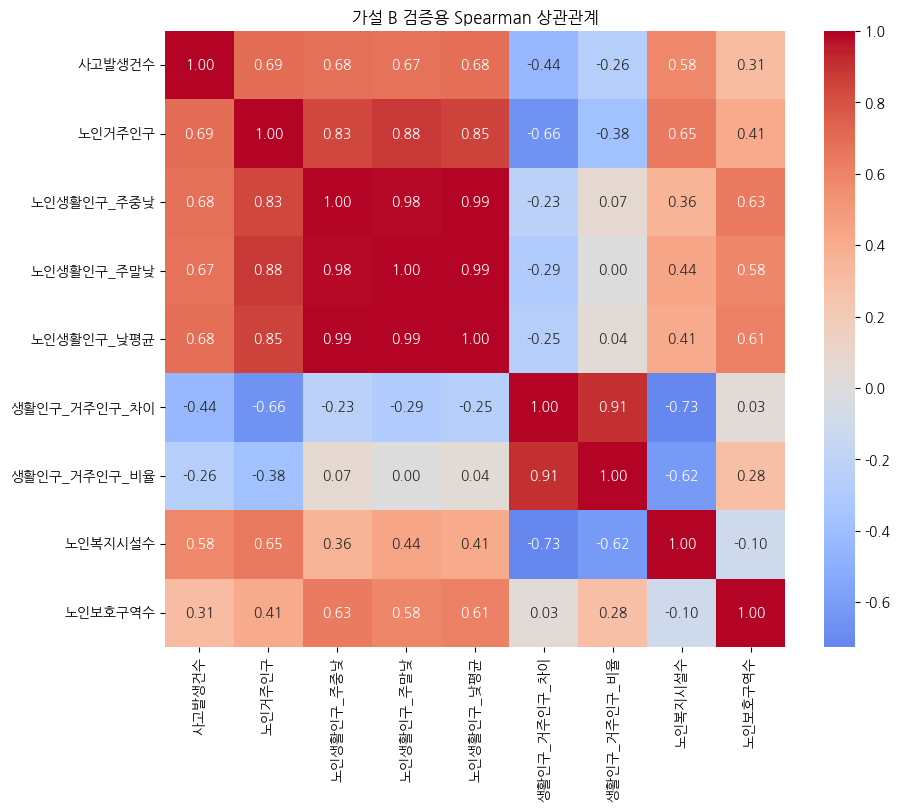

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(
    eda_gu[corr_cols].corr(method="spearman"),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("가설 B 검증용 Spearman 상관관계")
plt.show()

# 10. 우선관리 자치구 점수에 보호구역 반영

In [ ]:
# 주의: 노인보호구역수는 많을수록 위험하다는 뜻이 아니라,
# 이미 행정적으로 관리되고 있는 구역 수다. 그래서 우선관리점수에는 두 가지 방식이 가능함.

In [ ]:
# 방식 A: 보호구역도 위험 노출 지표로 포함

from sklearn.preprocessing import MinMaxScaler

score_cols = [
    "사고발생건수",
    "노인생활인구_낮평균",
    "생활인구_거주인구_비율",
    "노인복지시설수",
    "노인보호구역수"
]

scaler = MinMaxScaler()
eda_gu[[col + "_scaled" for col in score_cols]] = scaler.fit_transform(eda_gu[score_cols])

eda_gu["우선관리점수"] = (
    0.40 * eda_gu["사고발생건수_scaled"] +
    0.30 * eda_gu["노인생활인구_낮평균_scaled"] +
    0.15 * eda_gu["생활인구_거주인구_비율_scaled"] +
    0.10 * eda_gu["노인복지시설수_scaled"] +
    0.05 * eda_gu["노인보호구역수_scaled"]
)

priority_gu = eda_gu.sort_values("우선관리점수", ascending=False)

priority_gu[
    [
        "자치구",
        "사고발생건수",
        "노인거주인구",
        "노인생활인구_낮평균",
        "생활인구_거주인구_비율",
        "노인복지시설수",
        "노인보호구역수",
        "우선관리점수"
    ]
].head(10)

,자치구,사고발생건수,노인거주인구,노인생활인구_낮평균,생활인구_거주인구_비율,노인복지시설수,노인보호구역수,우선관리점수
17,송파구,332,122082.0,101948.982047,0.835079,22,24,0.721589
10,동대문구,417,74076.0,59316.219736,0.800737,23,9,0.612451
0,강남구,270,96850.0,96143.071414,0.992691,11,13,0.596477
3,강서구,275,115304.0,79835.756415,0.692388,31,12,0.527869
1,강동구,264,99790.0,81964.097079,0.821358,23,9,0.519347
21,은평구,297,104031.0,70812.041327,0.680676,24,11,0.499625
24,중랑구,305,89759.0,59204.824182,0.659590,48,3,0.487857
8,노원구,243,106236.0,81156.451796,0.763919,24,7,0.478746
16,성북구,275,88669.0,62666.033988,0.706733,24,8,0.435269
19,영등포구,253,74518.0,65983.465207,0.885458,19,4,0.429106


In [ ]:
# 방식 B: 보호구역 부족도를 반영
# 이 방식이 행정 효율화 목적에는 더 좋음.
# 생활인구와 사고가 많은데 보호구역은 적은 지역을 우선관리 대상으로 보는 방식.

eda_gu["보호구역_부족도"] = (
    eda_gu["사고발생건수_scaled"] +
    eda_gu["노인생활인구_낮평균_scaled"]
) / (eda_gu["노인보호구역수_scaled"] + 0.1)

In [ ]:
eda_gu["우선관리점수_보호구역부족반영"] = (
    0.45 * eda_gu["사고발생건수_scaled"] +
    0.30 * eda_gu["노인생활인구_낮평균_scaled"] +
    0.15 * eda_gu["생활인구_거주인구_비율_scaled"] +
    0.10 * eda_gu["보호구역_부족도"]
)

priority_gu_shortage = eda_gu.sort_values(
    "우선관리점수_보호구역부족반영",
    ascending=False
)

priority_gu_shortage[
    [
        "자치구",
        "사고발생건수",
        "노인거주인구",
        "노인생활인구_낮평균",
        "노인보호구역수",
        "보호구역_부족도",
        "우선관리점수_보호구역부족반영"
    ]
].head(10)

,자치구,사고발생건수,노인거주인구,노인생활인구_낮평균,노인보호구역수,보호구역_부족도,우선관리점수_보호구역부족반영
2,강북구,271,75413.0,54575.248701,2,8.863240,1.254986
24,중랑구,305,89759.0,59204.824182,3,7.264321,1.152571
6,구로구,261,89539.0,58627.140714,3,6.266719,0.988002
10,동대문구,417,74076.0,59316.219736,9,3.364774,0.941019
19,영등포구,253,74518.0,65983.465207,4,5.179996,0.933014
17,송파구,332,122082.0,101948.982047,24,1.577457,0.826095
0,강남구,270,96850.0,96143.071414,13,2.435518,0.824131
8,노원구,243,106236.0,81156.451796,7,3.571251,0.803405
1,강동구,264,99790.0,81964.097079,9,2.978192,0.785425
9,도봉구,166,79529.0,53270.376241,2,5.410737,0.749109


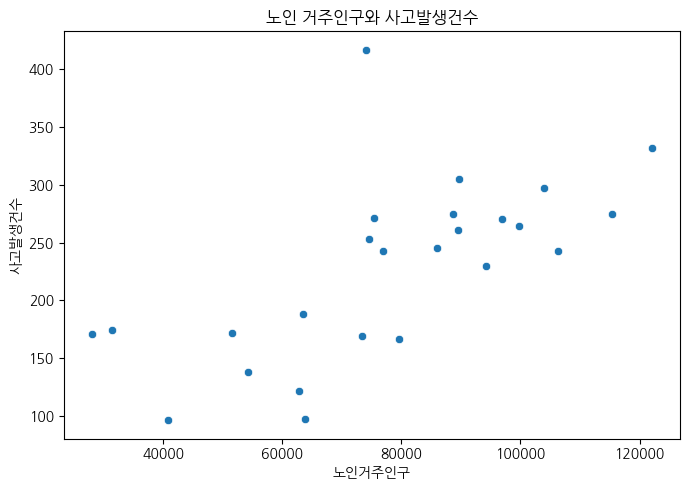

In [ ]:
# 거주인구 vs 생활인구 산점도 비교
plt.figure(figsize=(7, 5))
sns.scatterplot(data=eda_gu, x="노인거주인구", y="사고발생건수")
plt.title("노인 거주인구와 사고발생건수")
plt.xlabel("노인거주인구")
plt.ylabel("사고발생건수")
plt.tight_layout()
plt.show()

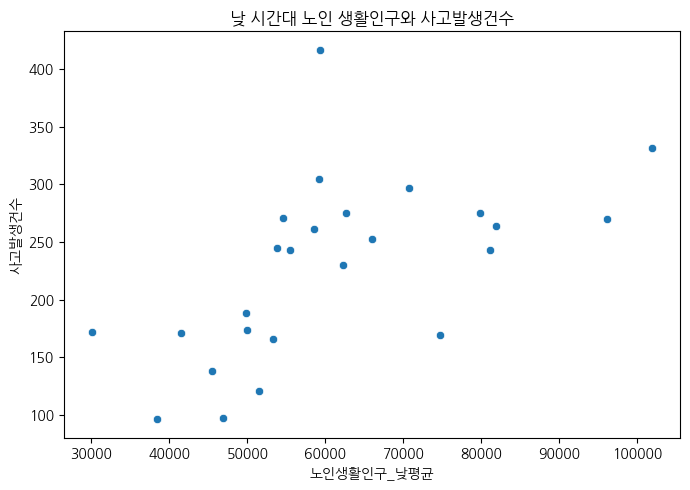

In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=eda_gu, x="노인생활인구_낮평균", y="사고발생건수")
plt.title("낮 시간대 노인 생활인구와 사고발생건수")
plt.xlabel("노인생활인구_낮평균")
plt.ylabel("사고발생건수")
plt.tight_layout()
plt.show()

In [ ]:
# 저번 eda분석에서 나온 결론은 이렇게 해석할 수 있음.
# 생활인구가 거주인구보다 더 중요하다는 가설은 기각하기 어렵지만, 거주인구와 생활인구 모두 사고발생건수와 관련이 있다.
# 그래서 주제의 방향성을 "노인 생활인구가 사고를 더 잘 설명하는가? 가 아니라
# 노인 보행 사고 위험은 높은데 보행안전 인프라가 부족한 지역은 어디인가? 로 설정하였다.

In [ ]:
# 주제: AI 기반 노인 보행안전 인프라 사각지대 탐지 및 개선 우선순위 추천 서비스

# 1. 라이브러리 및 기본설정

In [ ]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import zipfile
import shutil
import tempfile

from sklearn.preprocessing import MinMaxScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

base_path = "/mnt/data"

In [ ]:
# 한글 폰트
plt.rcParams["font.family"] = "NanumGothic"   # Colab
# plt.rcParams["font.family"] = "Malgun Gothic"  # Windows
# plt.rcParams["font.family"] = "AppleGothic"    # Mac
plt.rcParams["axes.unicode_minus"] = False

# 2. 자치구 코드 매핑

In [ ]:
# 도로시설 데이터에는 GU_CDE가 3자리 코드로 들어가 있어서 자치구명으로 바꿔줘야 함.
gu_code_map_3 = {
    110: "종로구",
    140: "중구",
    170: "용산구",
    200: "성동구",
    215: "광진구",
    230: "동대문구",
    260: "중랑구",
    290: "성북구",
    305: "강북구",
    320: "도봉구",
    350: "노원구",
    380: "은평구",
    410: "서대문구",
    440: "마포구",
    470: "양천구",
    500: "강서구",
    530: "구로구",
    545: "금천구",
    560: "영등포구",
    590: "동작구",
    620: "관악구",
    650: "서초구",
    680: "강남구",
    710: "송파구",
    740: "강동구"
}

sig_code_map = {
    "11110": "종로구",
    "11140": "중구",
    "11170": "용산구",
    "11200": "성동구",
    "11215": "광진구",
    "11230": "동대문구",
    "11260": "중랑구",
    "11290": "성북구",
    "11305": "강북구",
    "11320": "도봉구",
    "11350": "노원구",
    "11380": "은평구",
    "11410": "서대문구",
    "11440": "마포구",
    "11470": "양천구",
    "11500": "강서구",
    "11530": "구로구",
    "11545": "금천구",
    "11560": "영등포구",
    "11590": "동작구",
    "11620": "관악구",
    "11650": "서초구",
    "11680": "강남구",
    "11710": "송파구",
    "11740": "강동구"
}

# 3. ZIP 안의 SHP 읽는 함수

In [ ]:
# 과속방지턱, 횡단보도 데이터는 ZIP 안에 SHP가 들어있으니까 이 함수로 읽으면 됨.

def read_shp_from_zip(zip_path):
    with zipfile.ZipFile(zip_path) as z:
        shp_files = [name for name in z.namelist() if name.lower().endswith(".shp")]
        if len(shp_files) == 0:
            raise ValueError(f"SHP 파일이 없습니다: {zip_path}")
        shp_name = shp_files[0]

    gdf = gpd.read_file(f"zip://{zip_path}!{shp_name}")
    return gdf

In [ ]:
# 자치구별 개수 집계 함수

def count_by_gu_cde(gdf, count_col_name):
    temp = gdf.copy()
    temp["GU_CDE"] = pd.to_numeric(temp["GU_CDE"], errors="coerce")
    temp["자치구"] = temp["GU_CDE"].map(gu_code_map_3)

    result = (
        temp
        .dropna(subset=["자치구"])
        .groupby("자치구")
        .size()
        .reset_index(name=count_col_name)
    )

    return result

# 4. 과속방지턱 개수 집계

In [ ]:
import zipfile
import pyogrio
import pandas as pd
import os

def read_shp_attributes_from_zip(zip_path):
    """
    ZIP 안의 SHP 파일에서 geometry 없이 속성 테이블만 읽는 함수.
    geometry 오류가 있는 SHP도 자치구별 개수 집계에는 사용 가능.
    """
    with zipfile.ZipFile(zip_path) as z:
        shp_files = [name for name in z.namelist() if name.lower().endswith(".shp")]
        if len(shp_files) == 0:
            raise ValueError(f"SHP 파일이 없습니다: {zip_path}")
        shp_name = shp_files[0]

    # geometry 없이 속성만 읽기
    df = pyogrio.read_dataframe(
        f"zip://{zip_path}!{shp_name}",
        read_geometry=False
    )

    return pd.DataFrame(df)

In [ ]:
# 파일 읽기

hump_path = "/content/drive/MyDrive/노인 보행자 사고 데이터셋/과속방지턱 개수/A067_A(험프20250417) (1).zip"

hump_attr = read_shp_attributes_from_zip(hump_path)

hump_attr.head()

,STAT_CDE,MGRNU,EVE_CDE,A067_KND_C,OD_PE_CDE,GU_CDE,NW_PE_CDE,FLAG,VIEW_CDE,ROD_GBN_CD,TFC_BSS_CD,SIXID,ESB_YMD,CAE_YMD,HISID,CTK_MGRNU,HUMP_MGRNU,FRM_CDE,MNG_AGEN
0,001,16-0000009380,001,002,390,380,390,001,002,002,108,None,None,None,13701.0,2000-0000-000,16-009380,None,None
1,001,16-0000009381,001,002,390,380,390,001,002,002,108,None,None,None,13703.0,2000-0000-000,16-009381,None,None
2,001,16-0000009382,001,002,390,380,390,001,002,002,108,None,None,None,13706.0,2000-0000-000,16-009382,None,None
3,001,16-0000009383,001,002,390,380,390,001,002,002,108,None,None,None,13708.0,2000-0000-000,16-009383,None,None
4,001,16-0000009385,001,002,390,380,390,001,002,002,108,None,None,None,13711.0,2000-0000-000,16-009385,None,None


In [ ]:
# 컬럼 확인

hump_attr.columns

Index(['STAT_CDE', 'MGRNU', 'EVE_CDE', 'A067_KND_C', 'OD_PE_CDE', 'GU_CDE',
       'NW_PE_CDE', 'FLAG', 'VIEW_CDE', 'ROD_GBN_CD', 'TFC_BSS_CD', 'SIXID',
       'ESB_YMD', 'CAE_YMD', 'HISID', 'CTK_MGRNU', 'HUMP_MGRNU', 'FRM_CDE',
       'MNG_AGEN'],
      dtype='object')

In [ ]:
# GU_CDE가 있는지 확인

hump_attr[["GU_CDE"]].head()

,GU_CDE
0,380
1,380
2,380
3,380
4,380


In [ ]:
# 자치구별 과속방지턱 개수 집계

hump_attr["GU_CDE"] = pd.to_numeric(hump_attr["GU_CDE"], errors="coerce")
hump_attr["자치구"] = hump_attr["GU_CDE"].map(gu_code_map_3)

hump_gu = (
    hump_attr
    .dropna(subset=["자치구"])
    .groupby("자치구")
    .size()
    .reset_index(name="과속방지턱개수")
)

hump_gu.sort_values("과속방지턱개수", ascending=False).head(10)

,자치구,과속방지턱개수
11,서초구,2022
14,송파구,1055
4,구로구,1010
9,마포구,998
18,은평구,946
5,노원구,896
0,강남구,890
13,성북구,788
16,영등포구,778
10,서대문구,755


# 5. 횡단보도 개수 집계

In [ ]:
import zipfile
import pyogrio
import pandas as pd

def read_shp_attributes_from_zip(zip_path):
    with zipfile.ZipFile(zip_path) as z:
        shp_files = [name for name in z.namelist() if name.lower().endswith(".shp")]
        if len(shp_files) == 0:
            raise ValueError(f"SHP 파일이 없습니다: {zip_path}")
        shp_name = shp_files[0]

    df = pyogrio.read_dataframe(
        f"zip://{zip_path}!{shp_name}",
        read_geometry=False
    )

    return pd.DataFrame(df)

In [ ]:
# 횡단보도 파일 읽기

crosswalk_path = "/content/drive/MyDrive/노인 보행자 사고 데이터셋/횡단보도 개수/A004_A_횡단보도.zip"

crosswalk_attr = read_shp_attributes_from_zip(crosswalk_path)

crosswalk_attr.head()

,MGRNU,STAT_CDE,A004_KND_C,HOL,VEL,AW_SN_QUA,AW_SN_LENX,EVE_CDE,OD_PE_CDE,GU_CDE,DONG_CDE,JIBUN,NW_PE_CDE,WORK_CDE,VIEW_CDE,ROD_GBN_CD,TFC_BSS_CD,SIXID,ESB_YMD,CAE_YMD,HISID,CTK_MGRNU,CRS_MGRNU,FRM_CDE,CSS_CDE,RN_CDE,MNG_AGEN
0,06-0000000856,001,003,0.0,0.0,0.0,None,001,140,410,12000,319-16도,140,001,002,001,108,2371071,None,None,80290.0,2014-0107-077,06-000856,005,848,None,None
1,06-0000029775,001,003,0.0,0.0,0.0,None,001,170,560,11000,86천,170,001,002,001,104,3109192,None,None,37239.0,2008-0108-593,06-029775,004,1918,None,None
2,06-0000029776,001,003,0.0,0.0,0.0,None,001,170,560,11000,86-7천,170,001,002,001,104,3109171,None,None,37240.0,2008-0108-593,06-029776,004,None,None,None
3,06-0000029777,001,002,0.0,0.0,4.0,006,001,350,470,10200,121-1도,350,001,002,001,104,1295602,None,None,70922.0,2010-0108-082,06-029777,004,5392,None,None
4,06-0000029779,001,003,0.0,0.0,0.0,001,001,280,680,10100,807-16 도,410,001,002,002,106,None,None,None,40220.0,2008-0512-002,06-029779,005,None,None,None


In [ ]:
# 컬럼 확인

crosswalk_attr.columns

Index(['MGRNU', 'STAT_CDE', 'A004_KND_C', 'HOL', 'VEL', 'AW_SN_QUA',
       'AW_SN_LENX', 'EVE_CDE', 'OD_PE_CDE', 'GU_CDE', 'DONG_CDE', 'JIBUN',
       'NW_PE_CDE', 'WORK_CDE', 'VIEW_CDE', 'ROD_GBN_CD', 'TFC_BSS_CD',
       'SIXID', 'ESB_YMD', 'CAE_YMD', 'HISID', 'CTK_MGRNU', 'CRS_MGRNU',
       'FRM_CDE', 'CSS_CDE', 'RN_CDE', 'MNG_AGEN'],
      dtype='object')

In [ ]:
# 자치구 코드 컬럼 확인

[col for col in crosswalk_attr.columns if "GU" in col.upper() or "SIG" in col.upper() or "구" in col]

['GU_CDE']

In [ ]:
crosswalk_attr[["GU_CDE"]].head()

,GU_CDE
0,410
1,560
2,560
3,470
4,680


In [ ]:
# 자치구별 횡단보도 개수 집계

crosswalk_attr["GU_CDE"] = pd.to_numeric(crosswalk_attr["GU_CDE"], errors="coerce")
crosswalk_attr["자치구"] = crosswalk_attr["GU_CDE"].map(gu_code_map_3)

crosswalk_gu = (
    crosswalk_attr
    .dropna(subset=["자치구"])
    .groupby("자치구")
    .size()
    .reset_index(name="횡단보도개수")
)

crosswalk_gu.sort_values("횡단보도개수", ascending=False).head(10)

,자치구,횡단보도개수
0,강남구,2665
14,송파구,2160
16,영등포구,2122
2,강서구,2005
11,서초구,1989
9,마포구,1901
13,성북구,1824
4,구로구,1660
1,강동구,1619
15,양천구,1608


# 6. 교차로 개수 집계

In [ ]:
# 교차로 파일은 SHP/DBF 파일명이 서로 달라서 바로 읽으면 속성이 안 붙을 수 있음.
# 아래 코드는 임시 폴더에 이름을 맞춰서 복사한 뒤 읽는 방식.

def load_intersection_shp(base_path):
    temp_dir = tempfile.mkdtemp()

    file_map = {
        "shp": "/content/drive/MyDrive/노인 보행자 사고 데이터셋/교차로 개수/A008_P.shp",
        "shx": "/content/drive/MyDrive/노인 보행자 사고 데이터셋/교차로 개수/A008_P.shx",
        "dbf": "/content/drive/MyDrive/노인 보행자 사고 데이터셋/교차로 개수/A008_P.dbf",
        "prj": "/content/drive/MyDrive/노인 보행자 사고 데이터셋/교차로 개수/A008_P.prj",
        "cpg": "/content/drive/MyDrive/노인 보행자 사고 데이터셋/교차로 개수/A008_P.cpg"
    }

    for ext, src_name in file_map.items():
        src = os.path.join(base_path, src_name)
        dst = os.path.join(temp_dir, f"A008_P.{ext}")
        if os.path.exists(src):
            shutil.copy(src, dst)
        else:
            print("파일 없음:", src)

    gdf = gpd.read_file(os.path.join(temp_dir, "A008_P.shp"))
    return gdf

intersection = load_intersection_shp(base_path)

intersection.head()

/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: One or several characters couldn't be converted correctly from EUC-KR to UTF-8.  This warning will not be emitted anymore
  return ogr_read(


,CSS_NUM,ESB_YMD,CSS_NAM,A008_KND_C,LK_CS_CDE,GU_CDE,JIBUN,OD_PE_CDE,NW_PE_CDE,WORK_CDE,VIEW_CDE,CUST_NUM,CTT_CFN,MSE_NUM,ROD_GBN_CD,TFC_BSS_CD,MGRNU,SIXID,HISID,DONG_CDE,FRM_CDE,VFLAG,RN_CDE,MNG_AGEN,XCE,YCE,geometry
0,1266.0,None,신림2교,003,0.0,620,808-133천,290,290,001,002,None,None,None,001,105,82-0000000205,None,205.0,10200,None,N,None,None,194462.0,541962.0,POINT (194461.812 541962.294)
1,1267.0,None,신본교,001,0.0,620,산164-2 임,290,290,001,002,None,None,None,002,105,82-0000001198,2190152,1198.0,10200,None,N,None,None,194250.0,542012.0,POINT (194249.786 542011.656)
2,1269.0,None,신림1교,003,0.0,620,87-22대,290,290,001,002,None,None,None,002,105,82-0000000606,2180682,606.0,10200,None,N,None,None,193995.0,542158.0,POINT (193994.869 542158.309)
3,1271.0,None,신림교입구,002,0.0,620,1642-9도,290,290,001,002,None,None,None,001,105,82-0000002815,None,2815.0,10200,None,N,None,None,193798.0,542554.0,POINT (193797.646 542554.365)
4,1272.0,None,가야쇼핑,001,0.0,620,970-1대,290,290,001,002,None,None,None,001,105,82-0000000607,2182142,607.0,10200,None,N,None,None,193752.0,542982.0,POINT (193751.585 542982.286)


In [ ]:
# 구조 확인

intersection.info()
intersection.crs

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 8097 entries, 0 to 8096
Data columns (total 27 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   CSS_NUM     8097 non-null   float64 
 1   ESB_YMD     0 non-null      object  
 2   CSS_NAM     8097 non-null   object  
 3   A008_KND_C  8097 non-null   object  
 4   LK_CS_CDE   6208 non-null   float64 
 5   GU_CDE      8097 non-null   object  
 6   JIBUN       7305 non-null   object  
 7   OD_PE_CDE   7876 non-null   object  
 8   NW_PE_CDE   8097 non-null   object  
 9   WORK_CDE    8097 non-null   object  
 10  VIEW_CDE    8097 non-null   object  
 11  CUST_NUM    0 non-null      object  
 12  CTT_CFN     1 non-null      object  
 13  MSE_NUM     1 non-null      object  
 14  ROD_GBN_CD  8097 non-null   object  
 15  TFC_BSS_CD  8097 non-null   object  
 16  MGRNU       8097 non-null   object  
 17  SIXID       5395 non-null   object  
 18  HISID       8097 non-null   float64 
 19

<Projected CRS: EPSG:5186>
Name: KGD2002 / Central Belt 2010
Axis Info [cartesian]:
- X[north]: Northing (metre)
- Y[east]: Easting (metre)
Area of Use:
- name: Republic of Korea (South Korea) - onshore between 126°E and 128°E.
- bounds: (126.0, 33.14, 128.0, 38.33)
Coordinate Operation:
- name: Korea Central Belt 2010
- method: Transverse Mercator
Datum: Korean Geodetic Datum 2002
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [ ]:
# 자치구별 교차로 개수

intersection_gu = count_by_gu_cde(intersection, "교차로개수")

intersection_gu.sort_values("교차로개수", ascending=False).head(10)

,자치구,교차로개수
14,송파구,519
0,강남구,488
16,영등포구,459
11,서초구,454
2,강서구,451
1,강동구,403
15,양천구,392
5,노원구,391
4,구로구,353
9,마포구,346


# 7. 전통시장 수 / 여부 집계

In [ ]:
# 전통시장은 상권분석서비스 데이터에서 TRDAR_SE_1 == "전통시장"인 것만 사용하면 됨.

market_path = os.path.join(
    base_path,
    "/content/drive/MyDrive/노인 보행자 사고 데이터셋/전통시장 여부/서울시 상권분석서비스(영역-상권).shp"
)

market_all = gpd.read_file(market_path)

market_all.head()

,TRDAR_SE_C,TRDAR_SE_1,TRDAR_CD,TRDAR_CD_N,XCNTS_VALU,YDNTS_VALU,SIGNGU_CD,SIGNGU_CD_,ADSTRD_CD,ADSTRD_CD_,RELM_AR,geometry
0,A,골목상권,3110008,배화여자대학교(박노수미술관),197093.0,453418.0,11110,종로구,11110515,청운효자동,149264.0,"POLYGON ((196955.842 453722.114, 196958.669 45..."
1,U,관광특구,3001494,종로·청계 관광특구,199796.0,452274.0,11110,종로구,11110615,종로1·2·3·4가동,653127.0,"POLYGON ((201385.38 452513.725, 201385.284 452..."
2,R,전통시장,3130021,신설종합시장,201854.0,452569.0,11110,종로구,11110710,숭인2동,9800.0,"POLYGON ((201937.121 452552.083, 201872.576 45..."
3,R,전통시장,3130002,세종마을음식문화거리(금천교시장),197423.0,453030.0,11110,종로구,11110530,사직동,49557.0,"POLYGON ((197550.67 453079.887, 197554.026 453..."
4,R,전통시장,3130001,통인시장,197351.0,453449.0,11110,종로구,11110515,청운효자동,38280.0,"POLYGON ((197428.009 453548.216, 197436.697 45..."


In [ ]:
# 전통시장만 필터링

traditional_market = market_all[
    market_all["TRDAR_SE_1"] == "전통시장"
].copy()

traditional_market[["TRDAR_SE_1", "TRDAR_CD_N", "SIGNGU_CD_"]].head()

,TRDAR_SE_1,TRDAR_CD_N,SIGNGU_CD_
2,전통시장,신설종합시장,종로구
3,전통시장,세종마을음식문화거리(금천교시장),종로구
4,전통시장,통인시장,종로구
5,전통시장,동묘시장(동묘벼룩시장),종로구
6,전통시장,동대문상가D동,종로구


In [ ]:
# 자치구별 전통시장 수

market_gu = (
    traditional_market
    .groupby("SIGNGU_CD_")
    .size()
    .reset_index(name="전통시장수")
    .rename(columns={"SIGNGU_CD_": "자치구"})
)

market_gu["전통시장여부"] = (market_gu["전통시장수"] > 0).astype(int)

market_gu.sort_values("전통시장수", ascending=False).head(10)

,자치구,전통시장수,전통시장여부
23,중구,22,1
4,관악구,21,1
10,동대문구,20,1
19,영등포구,19,1
22,종로구,18,1
12,마포구,16,1
2,강북구,15,1
11,동작구,15,1
18,양천구,13,1
21,은평구,12,1


# 8. 도시공원 수 / 여부 집계

In [ ]:
# 도시공원 데이터는 자치구 속성이 없어,
# 1차 EDA에서는 공원 중심점 기준 가장 가까운 서울 도로구간의 자치구 코드를 매칭하여 자치구별 공원 수를 산출하였다.
# 향후 자치구 경계 데이터 확보 시 공간조인 방식으로 보완할 예정이다.

In [ ]:
park_path = os.path.join(base_path, "/content/drive/MyDrive/노인 보행자 사고 데이터셋/도시공원 여부/UPIS_SHP_ZON216.shp")
road_path = os.path.join(base_path, "/content/drive/MyDrive/노인 보행자 사고 데이터셋/(도로명주소)도로구간_서울/TL_SPRD_MANAGE_11_202604.shp")

park = gpd.read_file(park_path)
road = gpd.read_file(road_path)

park.head(), road.head()

/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: One or several characters couldn't be converted correctly from EUC-KR to UTF-8.  This warning will not be emitted anymore
  return ogr_read(


(                ID    CODE    ENT_NAME JOSER_ID GOSI_ID          LABEL  \
 0  생활서비스시설_공원_0033  ZON216  생활서비스시설_공원     None    None     강변공원(망원지구)   
 1  생활서비스시설_공원_0034  ZON216  생활서비스시설_공원     None    None  강변공원((광나루지구))   
 2  생활서비스시설_공원_0036  ZON216  생활서비스시설_공원     None    None     강변공원(잠실지구)   
 3  생활서비스시설_공원_0037  ZON216  생활서비스시설_공원     None    None      기타공원(월드컵)   
 4  생활서비스시설_공원_0038  ZON216  생활서비스시설_공원     None    None      근린공원(월드컵)   
 
   GOSI_DATE                                           geometry  
 0      None  POLYGON ((190588.499 450466.863, 190596.266 45...  
 1      None  POLYGON ((208176.172 446343.218, 208112.64 446...  
 2      None  POLYGON ((201267.186 446995.504, 201304.588 44...  
 3      None  MULTIPOLYGON (((189627.169 452578.9, 189656.28...  
 4      None  POLYGON ((188122.584 452638.342, 188124.178 45...  ,
    ALWNC_DE                      ALWNC_RESN BSI_INT                    ENG_RN  \
 0  20100628                     명륜길 일련번호 부여      10         Myeongny

In [ ]:
# 좌표계 확인

print("park crs:", park.crs)
print("road crs:", road.crs)

park crs: EPSG:5174
road crs: EPSG:5179


In [ ]:
# 공원 중심점 생성 후 가장 가까운 도로구간의 자치구 코드 매칭

# 분석용 좌표계 통일
park_5179 = park.to_crs(epsg=5179)
road_5179 = road.to_crs(epsg=5179)

# 공원 중심점 생성
park_centroid = park_5179.copy()
park_centroid["geometry"] = park_centroid.geometry.centroid

# 도로에서 필요한 컬럼만 사용
road_simple = road_5179[["SIG_CD", "geometry"]].copy()
road_simple["SIG_CD"] = road_simple["SIG_CD"].astype(str)

# 가장 가까운 도로구간 기준으로 자치구 코드 부여
park_join = gpd.sjoin_nearest(
    park_centroid,
    road_simple,
    how="left",
    distance_col="nearest_road_dist"
)

park_join["자치구"] = park_join["SIG_CD"].map(sig_code_map)

park_join[["LABEL", "자치구", "nearest_road_dist"]].head()

,LABEL,자치구,nearest_road_dist
0,강변공원(망원지구),마포구,36.478742
1,강변공원((광나루지구)),송파구,78.875747
2,강변공원(잠실지구),강남구,35.058899
3,기타공원(월드컵),마포구,435.586328
4,근린공원(월드컵),마포구,129.153200


In [ ]:
# 자치구별 도시공원 수

park_gu = (
    park_join
    .dropna(subset=["자치구"])
    .groupby("자치구")
    .size()
    .reset_index(name="도시공원수")
)

park_gu["도시공원여부"] = (park_gu["도시공원수"] > 0).astype(int)

park_gu.sort_values("도시공원수", ascending=False).head(10)

,자치구,도시공원수,도시공원여부
8,노원구,134,1
14,서초구,128,1
3,강서구,126,1
17,송파구,119,1
18,양천구,103,1
0,강남구,100,1
4,관악구,88,1
16,성북구,83,1
13,서대문구,82,1
1,강동구,76,1


# 9.기존 EDA 데이터에 새 변수 병합

In [ ]:
# 이 단계는 기존에 만들어둔 eda_gu가 있어야 함.
# eda_gu는 사고, 생활인구, 거주인구, 노인복지시설, 노인보호구역까지 붙어 있는 데이터.

eda_new = (
    eda_gu
    .merge(hump_gu, on="자치구", how="left")
    .merge(crosswalk_gu, on="자치구", how="left")
    .merge(intersection_gu, on="자치구", how="left")
    .merge(market_gu, on="자치구", how="left")
    .merge(park_gu, on="자치구", how="left")
)

new_cols = [
    "과속방지턱개수",
    "횡단보도개수",
    "교차로개수",
    "전통시장수",
    "전통시장여부",
    "도시공원수",
    "도시공원여부"
]

eda_new[new_cols] = eda_new[new_cols].fillna(0)

eda_new.head()

,자치구,사고발생건수,사망자수,중상자수,경상자수,부상신고자수,노인생활인구_주말낮,노인생활인구_주중낮,노인생활인구_낮평균,노인거주인구,노인복지시설수,노인보호구역수,생활인구_거주인구_차이,생활인구_거주인구_비율,사고발생건수_scaled,노인생활인구_낮평균_scaled,생활인구_거주인구_비율_scaled,노인복지시설수_scaled,노인보호구역수_scaled,우선관리점수,보호구역_부족도,우선관리점수_보호구역부족반영,과속방지턱개수,횡단보도개수,교차로개수,전통시장수,전통시장여부,도시공원수,도시공원여부
0,강남구,270,6,133,111,26,88135.850900,104150.291929,96143.071414,96850.0,11,13,-706.928586,0.992691,0.542056,0.919255,0.405853,0.18,0.500000,0.596477,2.435518,0.824131,890.0,2665.0,488.0,9,1,100,1
1,강동구,264,2,131,120,16,81992.858954,81935.335205,81964.097079,99790.0,23,9,-17825.902921,0.821358,0.523364,0.722061,0.236488,0.42,0.318182,0.519347,2.978192,0.785425,682.0,1619.0,403.0,9,1,76,1
2,강북구,271,10,134,136,11,55458.689670,53691.807732,54575.248701,75413.0,32,2,-20837.751299,0.723675,0.545171,0.341153,0.139928,0.60,0.000000,0.401404,8.863240,1.254986,0.0,0.0,0.0,15,1,53,1
3,강서구,275,11,129,114,30,79909.864280,79761.648551,79835.756415,115304.0,31,12,-35468.243585,0.692388,0.557632,0.692462,0.109000,0.58,0.454545,0.527869,2.254268,0.700450,682.0,2005.0,451.0,10,1,126,1
4,관악구,230,12,108,110,7,63384.096673,61238.851398,62311.474036,94167.0,27,13,-31855.525964,0.661705,0.417445,0.448744,0.078670,0.50,0.500000,0.388402,1.443649,0.478639,227.0,974.0,269.0,21,1,88,1


In [ ]:
# 결측치 확인

eda_new.isna().sum()

,0
자치구,0
사고발생건수,0
사망자수,0
중상자수,0
경상자수,0
부상신고자수,0
노인생활인구_주말낮,0
노인생활인구_주중낮,0
노인생활인구_낮평균,0
노인거주인구,0


In [ ]:
# 기본 통계 확인

eda_new[
    [
        "사고발생건수",
        "노인거주인구",
        "노인생활인구_낮평균",
        "노인복지시설수",
        "노인보호구역수",
        "과속방지턱개수",
        "횡단보도개수",
        "교차로개수",
        "전통시장수",
        "도시공원수"
    ]
].describe()

,사고발생건수,노인거주인구,노인생활인구_낮평균,노인복지시설수,노인보호구역수,과속방지턱개수,횡단보도개수,교차로개수,전통시장수,도시공원수
count,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.00000
mean,226.920000,77694.600000,61033.597020,19.400000,7.800000,666.040000,1365.840000,296.360000,12.200000,75.76000
std,76.741406,24470.519707,17365.323636,12.701706,4.830459,419.745208,669.355703,143.292207,5.016639,28.23898
min,96.000000,27996.000000,30045.024481,2.000000,2.000000,0.000000,0.000000,0.000000,2.000000,36.00000
25%,171.000000,63416.000000,49960.598776,10.000000,5.000000,426.000000,1068.000000,231.000000,9.000000,55.00000
50%,243.000000,76994.000000,58627.140714,19.000000,7.000000,682.000000,1479.000000,306.000000,11.000000,68.00000
75%,271.000000,94167.000000,70812.041327,24.000000,9.000000,890.000000,1824.000000,392.000000,15.000000,88.00000
max,417.000000,122082.000000,101948.982047,52.000000,24.000000,2022.000000,2665.000000,519.000000,22.000000,134.00000


# 10. EDA 1: 사고발생건수와 변수 상관분석

In [ ]:
infra_corr_cols = [
    "사고발생건수",
    "노인거주인구",
    "노인생활인구_낮평균",
    "노인복지시설수",
    "노인보호구역수",
    "과속방지턱개수",
    "횡단보도개수",
    "교차로개수",
    "전통시장수",
    "도시공원수"
]

corr_infra = eda_new[infra_corr_cols].corr(method="spearman")

corr_infra["사고발생건수"].sort_values(ascending=False)

,사고발생건수
사고발생건수,1.000000
노인거주인구,0.694113
노인생활인구_낮평균,0.684109
노인복지시설수,0.577376
교차로개수,0.460531
횡단보도개수,0.438090
과속방지턱개수,0.319469
도시공원수,0.312404
노인보호구역수,0.306565
전통시장수,0.093383


# 11. EDA 2: 히트맵

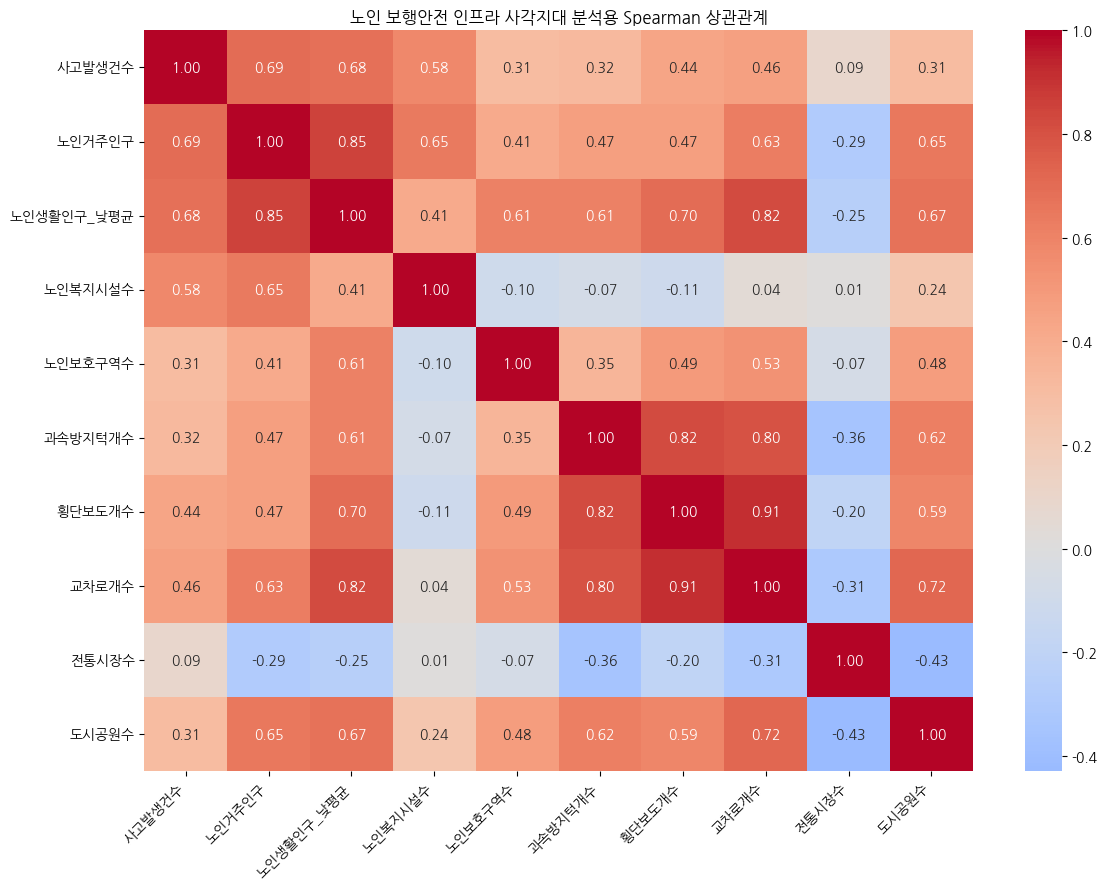

In [ ]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_infra,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("노인 보행안전 인프라 사각지대 분석용 Spearman 상관관계")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# 변수 간 상관관계를 확인한 결과, 사고발생건수와 노인 노출 변수, 보행 충돌 환경 변수, 안전 인프라 변수 간의 관계를 비교하였다.
# 이를 통해 단일 인구 변수보다 보행환경과 안전시설을 함께 고려한 통합 점수 모델이 필요함을 확인한다.

# 12. EDA 3: 주요 산점도

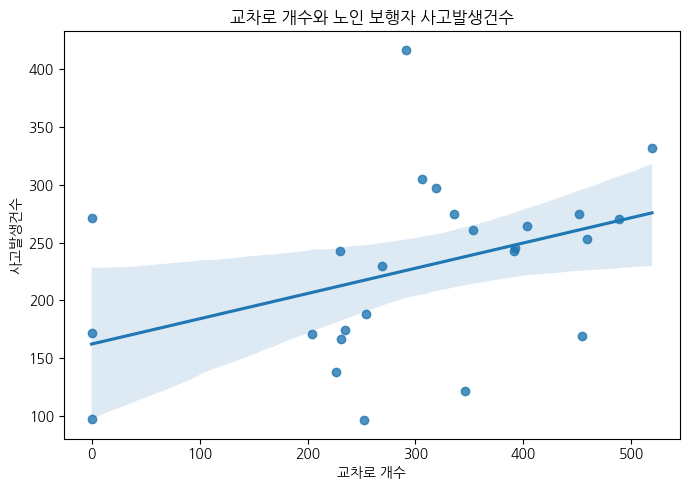

In [ ]:
# 교차로 개수와 사고발생건수

plt.figure(figsize=(7, 5))

sns.regplot(
    data=eda_new,
    x="교차로개수",
    y="사고발생건수"
)

plt.title("교차로 개수와 노인 보행자 사고발생건수")
plt.xlabel("교차로 개수")
plt.ylabel("사고발생건수")
plt.tight_layout()
plt.show()

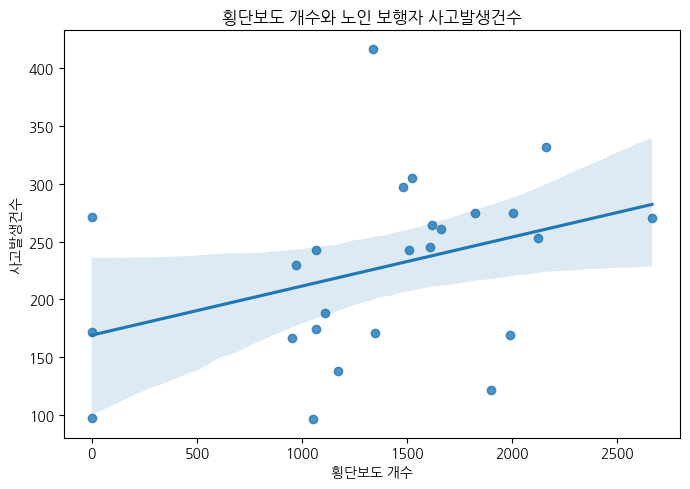

In [ ]:
# 횡단보도 개수와 사고발생건수

plt.figure(figsize=(7, 5))

sns.regplot(
    data=eda_new,
    x="횡단보도개수",
    y="사고발생건수"
)

plt.title("횡단보도 개수와 노인 보행자 사고발생건수")
plt.xlabel("횡단보도 개수")
plt.ylabel("사고발생건수")
plt.tight_layout()
plt.show()

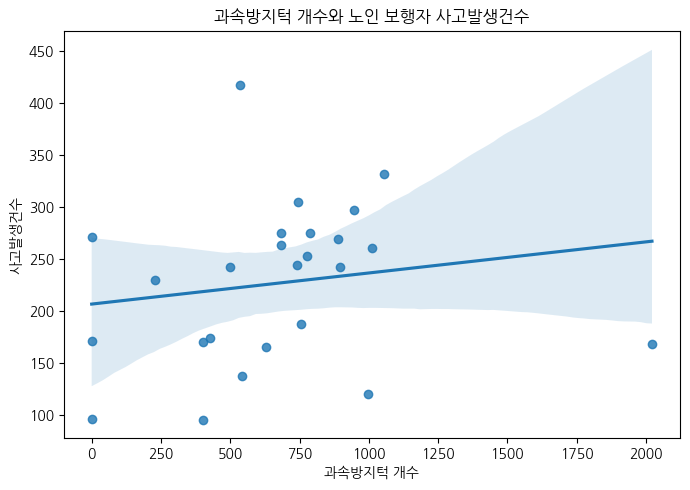

In [ ]:
# 과속방지턱 개수와 사고발생건수

plt.figure(figsize=(7, 5))

sns.regplot(
    data=eda_new,
    x="과속방지턱개수",
    y="사고발생건수"
)

plt.title("과속방지턱 개수와 노인 보행자 사고발생건수")
plt.xlabel("과속방지턱 개수")
plt.ylabel("사고발생건수")
plt.tight_layout()
plt.show()

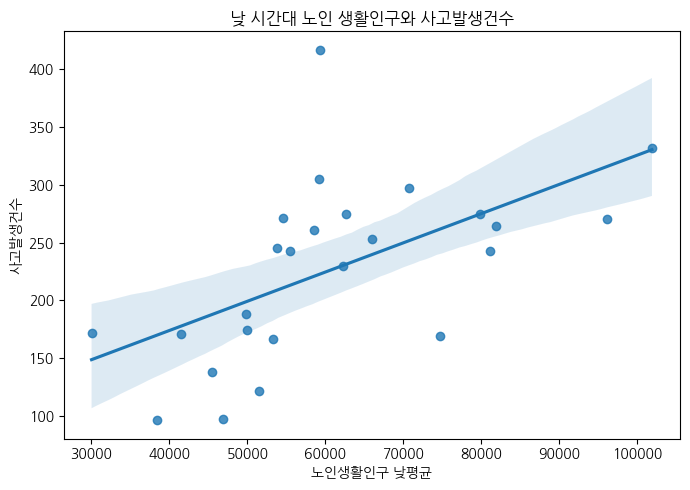

In [ ]:
# 노인생활인구와 사고발생건수

plt.figure(figsize=(7, 5))

sns.regplot(
    data=eda_new,
    x="노인생활인구_낮평균",
    y="사고발생건수"
)

plt.title("낮 시간대 노인 생활인구와 사고발생건수")
plt.xlabel("노인생활인구 낮평균")
plt.ylabel("사고발생건수")
plt.tight_layout()
plt.show()

# 13. 핵심 지표 만들기

In [ ]:
# | 점수         | 의미                                   |
# | ---------- | ------------------------------------ |
# | `사고위험점수`   | 사고와 노인 노출이 높은 정도                     |
# | `보행충돌노출점수` | 교차로, 횡단보도, 시장, 공원 등 보행 충돌 가능성이 높은 정도 |
# | `안전인프라점수`  | 보호구역, 과속방지턱 등 기존 안전관리 수준             |
# | `사각지대점수`   | 위험은 높은데 안전 인프라가 부족한 정도               |

In [ ]:
# 점수 계산용 변수 스케일링

score_cols = [
    "사고발생건수",
    "노인거주인구",
    "노인생활인구_낮평균",
    "노인복지시설수",
    "노인보호구역수",
    "과속방지턱개수",
    "횡단보도개수",
    "교차로개수",
    "전통시장수",
    "도시공원수"
]

scaler = MinMaxScaler()

eda_new[[col + "_scaled" for col in score_cols]] = scaler.fit_transform(
    eda_new[score_cols]
)

In [ ]:
# 사고위험점수
# 실제 사고가 많고, 노인 생활·거주 인구 및 노인시설이 많은 지역일수록 높다.

eda_new["사고위험점수"] = (
    0.40 * eda_new["사고발생건수_scaled"] +
    0.25 * eda_new["노인생활인구_낮평균_scaled"] +
    0.20 * eda_new["노인거주인구_scaled"] +
    0.15 * eda_new["노인복지시설수_scaled"]
)

In [ ]:
# 보행충돌노출점수
# 차량과 보행자가 만날 가능성이 높은 환경일수록 높다.

eda_new["보행충돌노출점수"] = (
    0.40 * eda_new["교차로개수_scaled"] +
    0.30 * eda_new["횡단보도개수_scaled"] +
    0.20 * eda_new["전통시장수_scaled"] +
    0.10 * eda_new["도시공원수_scaled"]
)

In [ ]:
# 안전인프라점수
# 이미 노인보호구역이나 속도저감시설이 많이 설치된 지역일수록 높다.

eda_new["안전인프라점수"] = (
    0.60 * eda_new["노인보호구역수_scaled"] +
    0.40 * eda_new["과속방지턱개수_scaled"]
)

In [ ]:
# 최종 사각지대점수
# 사고위험과 보행충돌 노출은 높은데 안전 인프라가 상대적으로 부족한 지역일수록 높다.

eda_new["사각지대점수"] = (
    eda_new["사고위험점수"] + eda_new["보행충돌노출점수"]
) / (eda_new["안전인프라점수"] + 0.1)

In [ ]:
eda_new["개선우선순위"] = eda_new["사각지대점수"].rank(
    ascending=False,
    method="dense"
).astype(int)

final_rank = eda_new.sort_values("개선우선순위")[
    [
        "개선우선순위",
        "자치구",
        "사고발생건수",
        "노인거주인구",
        "노인생활인구_낮평균",
        "노인복지시설수",
        "노인보호구역수",
        "과속방지턱개수",
        "횡단보도개수",
        "교차로개수",
        "전통시장수",
        "도시공원수",
        "사고위험점수",
        "보행충돌노출점수",
        "안전인프라점수",
        "사각지대점수"
    ]
]

final_rank.head(10)

,개선우선순위,자치구,사고발생건수,노인거주인구,노인생활인구_낮평균,노인복지시설수,노인보호구역수,과속방지턱개수,횡단보도개수,교차로개수,전통시장수,도시공원수,사고위험점수,보행충돌노출점수,안전인프라점수,사각지대점수
2,1,강북구,271,75413.0,54575.248701,32,2,0.0,0.0,0.0,15,53,0.494152,0.147347,0.000000,6.414986
24,2,중랑구,305,89759.0,59204.824182,48,3,743.0,1524.0,306.0,12,72,0.631111,0.544130,0.174256,4.285199
19,3,영등포구,253,74518.0,65983.465207,19,4,778.0,2122.0,459.0,19,57,0.470484,0.784060,0.208452,4.067220
9,4,도봉구,166,79529.0,53270.376241,52,2,628.0,952.0,231.0,10,57,0.427523,0.386630,0.124233,3.630830
6,5,구로구,261,89539.0,58627.140714,15,3,1010.0,1660.0,353.0,9,71,0.474806,0.564643,0.227075,3.178015
10,6,동대문구,417,74076.0,59316.219736,23,9,537.0,1340.0,291.0,20,47,0.662725,0.566346,0.297141,3.094801
8,7,노원구,243,106236.0,81156.451796,24,7,896.0,1509.0,391.0,6,134,0.593201,0.611217,0.313614,2.911938
18,8,양천구,245,85974.0,53849.127571,18,7,741.0,1608.0,392.0,13,103,0.439678,0.661500,0.282951,2.875505
1,9,강동구,264,99790.0,81964.097079,23,9,682.0,1619.0,403.0,9,76,0.605475,0.603665,0.325825,2.839523
3,10,강서구,275,115304.0,79835.756415,31,12,682.0,2005.0,451.0,10,126,0.668760,0.745132,0.407643,2.785208


# 14. 사각지대 TOP 10 추출

In [ ]:
blindspot_top10 = final_rank.head(10)

blindspot_top10

,개선우선순위,자치구,사고발생건수,노인거주인구,노인생활인구_낮평균,노인복지시설수,노인보호구역수,과속방지턱개수,횡단보도개수,교차로개수,전통시장수,도시공원수,사고위험점수,보행충돌노출점수,안전인프라점수,사각지대점수
2,1,강북구,271,75413.0,54575.248701,32,2,0.0,0.0,0.0,15,53,0.494152,0.147347,0.000000,6.414986
24,2,중랑구,305,89759.0,59204.824182,48,3,743.0,1524.0,306.0,12,72,0.631111,0.544130,0.174256,4.285199
19,3,영등포구,253,74518.0,65983.465207,19,4,778.0,2122.0,459.0,19,57,0.470484,0.784060,0.208452,4.067220
9,4,도봉구,166,79529.0,53270.376241,52,2,628.0,952.0,231.0,10,57,0.427523,0.386630,0.124233,3.630830
6,5,구로구,261,89539.0,58627.140714,15,3,1010.0,1660.0,353.0,9,71,0.474806,0.564643,0.227075,3.178015
10,6,동대문구,417,74076.0,59316.219736,23,9,537.0,1340.0,291.0,20,47,0.662725,0.566346,0.297141,3.094801
8,7,노원구,243,106236.0,81156.451796,24,7,896.0,1509.0,391.0,6,134,0.593201,0.611217,0.313614,2.911938
18,8,양천구,245,85974.0,53849.127571,18,7,741.0,1608.0,392.0,13,103,0.439678,0.661500,0.282951,2.875505
1,9,강동구,264,99790.0,81964.097079,23,9,682.0,1619.0,403.0,9,76,0.605475,0.603665,0.325825,2.839523
3,10,강서구,275,115304.0,79835.756415,31,12,682.0,2005.0,451.0,10,126,0.668760,0.745132,0.407643,2.785208


# 15. 사각지대 TOP 10 시각화

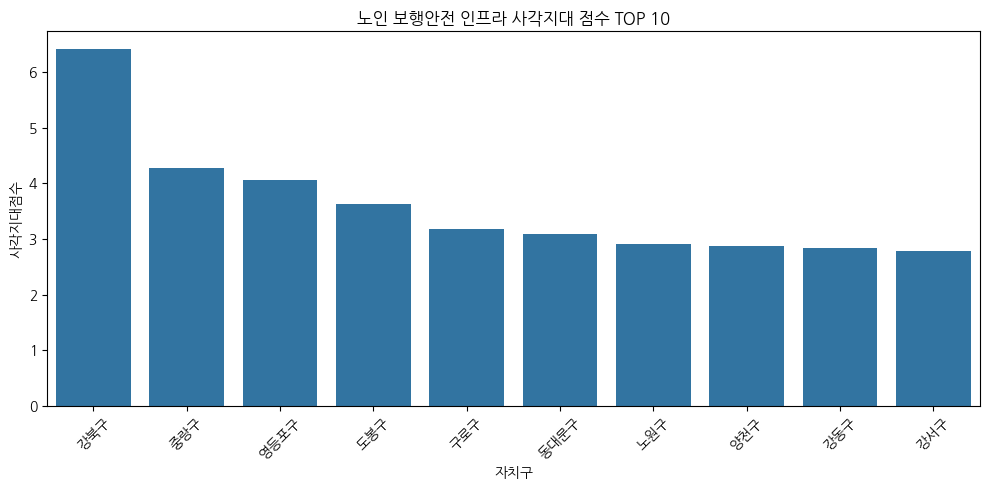

In [ ]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=blindspot_top10,
    x="자치구",
    y="사각지대점수"
)

plt.title("노인 보행안전 인프라 사각지대 점수 TOP 10")
plt.xlabel("자치구")
plt.ylabel("사각지대점수")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 16. 사고위험점수 vs 안전인프라점수 비교

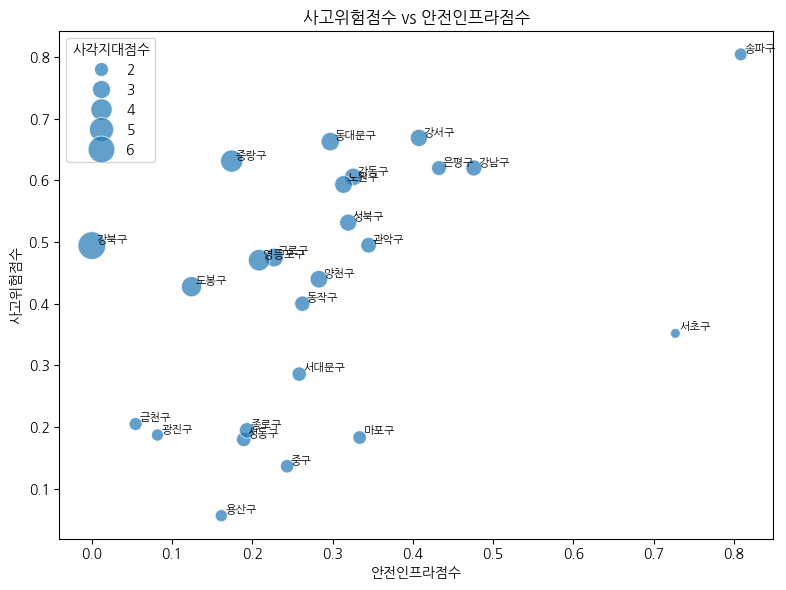

In [ ]:
# 주제를 가장 잘 보여줌

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=eda_new,
    x="안전인프라점수",
    y="사고위험점수",
    size="사각지대점수",
    sizes=(50, 400),
    alpha=0.7
)

for _, row in eda_new.iterrows():
    plt.text(
        row["안전인프라점수"] + 0.005,
        row["사고위험점수"] + 0.005,
        row["자치구"],
        fontsize=8
    )

plt.title("사고위험점수 vs 안전인프라점수")
plt.xlabel("안전인프라점수")
plt.ylabel("사고위험점수")
plt.tight_layout()
plt.show()

In [ ]:
# 사고위험점수는 높지만 안전인프라점수가 낮은 자치구는
# 기존 안전시설 배치가 사고위험 수준을 충분히 따라가지 못하는 지역으로 볼 수 있으며, 우선적인 정책 개입이 필요하다.

# 17. 최종 EDA 데이터 저장

In [ ]:
eda_new.to_csv(
    "노인보행안전_인프라사각지대_EDA_최종데이터.csv",
    index=False,
    encoding="utf-8-sig"
)

blindspot_top10.to_csv(
    "노인보행안전_인프라사각지대_TOP10.csv",
    index=False,
    encoding="utf-8-sig"
)

# 18. 결론

In [ ]:
# 본 EDA에서는 노인 보행자 사고위험을 단일 인구 변수로 설명하기보다, 사고 이력, 노인 인구 노출, 보행 충돌 가능 환경, 기존 안전 인프라를 종합적으로 분석하였다.
# 분석을 위해 자치구별 사고발생건수, 노인거주인구, 낮 시간대 노인생활인구, 노인복지시설 수, 노인보호구역 수, 과속방지턱 수, 횡단보도 수, 교차로 수, 전통시장 수, 도시공원 수를 결합하였다.
# Spearman 상관분석과 산점도 분석을 통해 사고발생건수와 노인 노출 변수 및 보행환경 변수 간의 관계를 확인하였고, 이후 사고위험점수, 보행충돌노출점수, 안전인프라점수를 산출하였다.
# 최종적으로 위험 수준 대비 안전 인프라가 부족한 정도를 나타내는 사각지대점수를 계산하여 개선 우선순위가 높은 자치구를 도출하였다.
# 이를 통해 기존 사고다발지역 중심 접근에서 벗어나, 사고위험은 높지만 안전시설이 상대적으로 부족한 지역을 선제적으로 탐지할 수 있으며,
# 보호구역 확대, 과속방지턱 설치, 횡단보도 개선, 교차로 신호체계 조정 등의 정책 우선순위 설정에 활용할 수 있다.

# 모델 이름과 구조 정리

In [ ]:
# 모델명: 노인 보행안전 인프라 사각지대 우선순위 산정 모델
# 모델 목적: 사고위험과 보행 충돌 노출은 높지만, 노인보호구역·과속방지턱 등 안전 인프라가 상대적으로 부족한 자치구를 우선관리지역으로 선정한다.

# 모델 산식 정리

In [ ]:
# 사고위험점수: 실제 사고가 많고, 노인 인구 노출과 노인 관련 시설이 많은 지역일수록 사고위험점수가 높다.

# 사고위험점수 = 0.40 × 사고발생건수_scaled + 0.25 × 노인생활인구_낮평균_scaled + 0.20 × 노인거주인구_scaled + 0.15 × 노인복지시설수_scaled

In [ ]:
# 보행충돌노출점수: 차량과 보행자가 만날 가능성이 높은 도로·생활 환경일수록 보행충돌노출점수가 높다.
# 보행충돌노출점수 = 0.40 × 교차로개수_scaled + 0.30 × 횡단보도개수_scaled + 0.20 × 전통시장수_scaled + 0.10 × 도시공원수_scaled

In [ ]:
# 안전인프라점수: 노인보호구역과 속도저감시설이 많이 설치된 지역일수록 안전인프라점수가 높다.
# 안전인프라점수 = 0.60 × 노인보호구역수_scaled + 0.40 × 과속방지턱개수_scaled

In [ ]:
# 최종 사각지대점수: 사고위험과 보행 충돌 노출은 높지만 안전 인프라가 부족한 지역일수록 사각지대점수가 높다.
# 사각지대점수 = (사고위험점수 + 보행충돌노출점수) / (안전인프라점수 + 0.1)

# 결과 해석 문장 작성

In [ ]:
# 본 분석에서는 자치구별 사고위험점수, 보행충돌노출점수, 안전인프라점수를 산출한 뒤, 위험 수준 대비 안전 인프라가 부족한 정도를 사각지대점수로 정의하였다.
# 사각지대점수가 높은 자치구는 노인 보행자 사고 위험과 보행 충돌 가능성이 높지만, 노인보호구역 및 과속방지턱 등 안전 인프라가 상대적으로 부족한 지역으로 해석할 수 있다.
# 따라서 해당 지역은 보호구역 추가 지정, 과속방지턱 설치, 횡단보도 개선, 교차로 신호체계 조정 등의 정책 개입이 우선적으로 필요한 지역이다.

# 비즈니스/서비스 방향

In [ ]:
# 정의: 노인 보행자 사고위험, 보행 충돌 환경, 안전 인프라 수준을 종합 분석하여 서울시 내 보행안전 인프라 사각지대를 탐지하고, 자치구별 개선 우선순위를 제공하는 공공 의사결정 지원 서비스이다.

In [ ]:
# 본 서비스는 사고위험이 높은 지역을 선제적으로 탐지하여 노인 보행자 사고 예방에 기여할 수 있다.
# 또한 한정된 예산과 행정 인력을 우선순위가 높은 지역에 집중 투입할 수 있어 행정 효율성을 높인다.
# 나아가 사고발생건수뿐 아니라 생활인구, 보행환경, 안전 인프라를 함께 고려하기 때문에 기존 사고다발지역 중심 정책보다 더 정교한 데이터 기반 의사결정을 지원할 수 있다.

In [ ]:
import pandas as pd
import numpy as np
import os

base_path = "/content/drive/MyDrive/노인 보행자 사고 데이터셋"

# 폴더 안 파일명 확인
for file in os.listdir(base_path):
    print(file)

LOCAL_PEOPLE_GU_2022.csv
LOCAL_PEOPLE_GU_2023.csv
LOCAL_PEOPLE_GU_2024.csv
사고분석 -지역별.xlsx
서울시 노인의료복지시설현황.xlsx
서울시 등록인구(연령별:동별) 통계.xlsx
노인_장애인보호구역_지정현황_2022_3월.xlsx
노인_장애인보호구역_지정현황_2022_12월.xlsx
노인_장애인보호구역_지정현황_2023_6월.xlsx
노인_장애인보호구역_지정현황_2023_12월.xlsx
노인_장애인보호구역_지정현황_2024_6월.xlsx
노인_장애인보호구역_지정현황_2024_12월.xlsx
과속방지턱 개수
횡단보도 개수
교차로 개수
도시공원 여부
전통시장 여부
(도로명주소)도로구간_서울
도로구간별 추정 유동인구.csv
서울시 자치구 횡단보도 정보 (1).csv
서울시 전통시장 현황(2025.7.31.기준).xlsx
교통사고+현황(연령층별+사상자)_20260506163932.csv


In [ ]:
acc_injury_path = os.path.join(
    base_path,
    "/content/drive/MyDrive/노인 보행자 사고 데이터셋/교통사고+현황(연령층별+사상자)_20260506163932.csv"
)

In [ ]:
encodings = ["utf-8-sig", "utf-8", "cp949", "euc-kr"]

df_acc_raw = None

for enc in encodings:
    try:
        df_acc_raw = pd.read_csv(acc_injury_path, encoding=enc)
        print("성공한 인코딩:", enc)
        break
    except UnicodeDecodeError:
        print("실패한 인코딩:", enc)

if df_acc_raw is None:
    raise ValueError("utf-8-sig, utf-8, cp949, euc-kr 모두 실패했습니다. 파일 형식을 다시 확인해야 합니다.")

print(df_acc_raw.shape)
print(df_acc_raw.columns.tolist())
display(df_acc_raw.head(15))

성공한 인코딩: utf-8-sig
(54, 14)
['자치구별(1)', '자치구별(2)', '항목', '2024', '2024.1', '2024.2', '2024.3', '2024.4', '2024.5', '2024.6', '2024.7', '2024.8', '2024.9', '2024.10']


,자치구별(1),자치구별(2),항목,2024,2024.1,2024.2,2024.3,2024.4,2024.5,2024.6,2024.7,2024.8,2024.9,2024.10
0,자치구별(1),자치구별(2),항목,합계,합계,합계,합계,합계,합계,합계,합계,합계,합계,합계
1,자치구별(1),자치구별(2),항목,소계,12세이하,13~20세,21~30세,31~40세,41~50세,51~60세,61-64세,65~70세,71세이상,불명
2,합계,소계,사망자수,212,2,1,21,14,15,34,18,28,79,-
3,합계,소계,부상자수,44327,1338,1660,7391,9218,8062,7463,2874,3143,3166,12
4,합계,종로구,사망자수,5,-,-,1,1,-,1,-,-,2,-
5,합계,종로구,부상자수,1253,20,47,230,247,229,214,84,104,76,2
6,합계,중구,사망자수,16,-,-,1,3,4,6,-,1,1,-
7,합계,중구,부상자수,1236,26,22,214,265,241,202,78,85,103,-
8,합계,용산구,사망자수,12,-,-,4,2,-,1,1,2,2,-
9,합계,용산구,부상자수,1174,22,27,228,275,208,215,69,59,71,-


In [ ]:
df_acc = df_acc_raw.copy()

# 혹시 앞 2행이 설명행이면 제거
display(df_acc.head(5))

,자치구별(1),자치구별(2),항목,2024,2024.1,2024.2,2024.3,2024.4,2024.5,2024.6,2024.7,2024.8,2024.9,2024.10
0,자치구별(1),자치구별(2),항목,합계,합계,합계,합계,합계,합계,합계,합계,합계,합계,합계
1,자치구별(1),자치구별(2),항목,소계,12세이하,13~20세,21~30세,31~40세,41~50세,51~60세,61-64세,65~70세,71세이상,불명
2,합계,소계,사망자수,212,2,1,21,14,15,34,18,28,79,-
3,합계,소계,부상자수,44327,1338,1660,7391,9218,8062,7463,2874,3143,3166,12
4,합계,종로구,사망자수,5,-,-,1,1,-,1,-,-,2,-


In [ ]:
df_acc = df_acc_raw.iloc[2:].copy()

df_acc.columns = [
    "광역", "자치구", "항목", "합계",
    "12세이하", "13~20세", "21~30세", "31~40세",
    "41~50세", "51~60세", "61~64세",
    "65~70세", "71세이상", "기타"
]

for col in ["광역", "자치구", "항목"]:
    df_acc[col] = df_acc[col].astype(str).str.strip()

display(df_acc.head())
print(df_acc["항목"].value_counts())

,광역,자치구,항목,합계,12세이하,13~20세,21~30세,31~40세,41~50세,51~60세,61~64세,65~70세,71세이상,기타
2,합계,소계,사망자수,212,2,1,21,14,15,34,18,28,79,-
3,합계,소계,부상자수,44327,1338,1660,7391,9218,8062,7463,2874,3143,3166,12
4,합계,종로구,사망자수,5,-,-,1,1,-,1,-,-,2,-
5,합계,종로구,부상자수,1253,20,47,230,247,229,214,84,104,76,2
6,합계,중구,사망자수,16,-,-,1,3,4,6,-,1,1,-


항목
사망자수    26
부상자수    26
Name: count, dtype: int64


In [ ]:
df_acc_injury = df_acc[
    df_acc["항목"].astype(str).str.contains("부상", na=False) &
    (df_acc["자치구"] != "소계")
].copy()

df_acc_injury["65~70세"] = pd.to_numeric(df_acc_injury["65~70세"], errors="coerce").fillna(0)
df_acc_injury["71세이상"] = pd.to_numeric(df_acc_injury["71세이상"], errors="coerce").fillna(0)

df_acc_injury["노인부상자수"] = (
    df_acc_injury["65~70세"] + df_acc_injury["71세이상"]
)

df_acc_gu = df_acc_injury[["자치구", "노인부상자수"]].reset_index(drop=True)

print(df_acc_gu.shape)
print(df_acc_gu["자치구"].nunique())
display(df_acc_gu.head(30))

(25, 2)
25


,자치구,노인부상자수
0,종로구,180
1,중구,188
2,용산구,130
3,성동구,142
4,광진구,119
5,동대문구,360
6,중랑구,305
7,성북구,290
8,강북구,220
9,도봉구,145


In [ ]:
cross_path = os.path.join(base_path, "/content/drive/MyDrive/노인 보행자 사고 데이터셋/서울시 자치구 횡단보도 정보 (1).csv")

df_cross = pd.read_csv(cross_path, encoding="cp949")

print(df_cross.shape)
print(df_cross.columns.tolist())
display(df_cross.head())

(40282, 13)
['연번', '시도명', '시군구명', '소재지지번주소', '횡단보도관리번호', '횡단보도종류', '고원식횡단보도유무', '경도', '위도', '보행등유무', '음향신호기설치여부', '보행자작동신호기유무', '데이터기준일자']


,연번,시도명,시군구명,소재지지번주소,횡단보도관리번호,횡단보도종류,고원식횡단보도유무,경도,위도,보행등유무,음향신호기설치여부,보행자작동신호기유무,데이터기준일자
0,1,서울특별시,강남구,강남구 개포동 12 대,06-0000029759,이단(화살표있음),N,37.493112,127.075840,N,N,N,2026-03-20
1,2,서울특별시,강남구,강남구 개포동 12 대,06-0000029761,일단(화살표없음),N,37.493547,127.074267,N,N,N,2026-03-20
2,3,서울특별시,강남구,강남구 개포동 12 대,06-0000029760,일단(화살표없음),N,37.493389,127.074755,N,N,N,2026-03-20
3,4,서울특별시,강남구,강남구 개포동 1280 대,06-0000047267,일단(화살표없음),N,37.480410,127.063586,Y,Y,N,2026-03-20
4,5,서울특별시,강남구,강남구 개포동 1280-1 도,06-0000007851,일단(화살표없음),N,37.482455,127.062366,N,N,N,2026-03-20


In [ ]:
df_cross.columns = df_cross.columns.str.strip()

In [ ]:
cross_gu = df_cross.groupby("시군구명").agg(
    횡단보도수=("연번", "count"),
    음향신호기_설치율=("음향신호기설치여부", lambda x: (x == "Y").sum() / len(x)),
    고원식_설치율=("고원식횡단보도유무", lambda x: (x == "Y").sum() / len(x)),
    보행등_설치율=("보행등유무", lambda x: (x == "Y").sum() / len(x))
).reset_index().rename(columns={"시군구명": "자치구"})

print(cross_gu.shape)
print(cross_gu["자치구"].nunique())
display(cross_gu.head(30))

(25, 5)
25


,자치구,횡단보도수,음향신호기_설치율,고원식_설치율,보행등_설치율
0,강남구,2745,0.248087,0.042623,0.287796
1,강동구,1808,0.338496,0.070796,0.411504
2,강북구,1313,0.234577,0.067022,0.281797
3,강서구,2179,0.363469,0.007343,0.400642
4,관악구,1039,0.329163,0.023099,0.392685
5,광진구,1115,0.299552,0.025112,0.356951
6,구로구,1810,0.275138,0.032597,0.324862
7,금천구,977,0.303992,0.056295,0.365404
8,노원구,1706,0.318875,0.032239,0.398593
9,도봉구,1116,0.263441,0.086022,0.340502


In [ ]:
market_path = os.path.join(base_path, "/content/drive/MyDrive/노인 보행자 사고 데이터셋/서울시 전통시장 현황(2025.7.31.기준).xlsx")

df_mkt = pd.read_excel(market_path)

print(df_mkt.shape)
print(df_mkt.columns.tolist())
display(df_mkt.head())

(459, 9)
['연번', '자치구 ', '시장명 ', '신주소(도로명 주소)', '구주소(번지주소)', '유형', '형태', '건물연면적', '점포수']


,연번,자치구,시장명,신주소(도로명 주소),구주소(번지주소),유형,형태,건물연면적,점포수
0,총계,서울시,433,NaN,NaN,NaN,NaN,NaN,NaN
1,소계,종로구,30,NaN,NaN,NaN,NaN,NaN,NaN
2,1,종로구,광장시장,종로구 창경궁로 88 광장시장,종로구 예지동 6-1,등록시장,건물형,18975.0,1579.0
3,2,종로구,광장전통시장,종로구 창경궁로 88 일대 광장전통시장,종로구 예지동 293-1,상점가,골목형,49384.0,1830.0
4,3,종로구,낙원악기상가,서울 종로구 삼일대로 428 낙원상가,종로구 낙원동 256,인정시장,건물형,20398.0,289.0


In [ ]:
df_mkt.columns = df_mkt.columns.str.strip()

df_mkt = df_mkt.rename(columns={
    "자치구 ": "자치구",
    "시장명 ": "시장명"
})

In [ ]:
df_mkt = df_mkt[
    ~df_mkt["연번"].astype(str).isin(["총계", "소계", "nan"])
].copy()

In [ ]:
df_mkt = df_mkt[
    ~df_mkt["시장명"].astype(str).str.contains("지하도상점가|지하쇼핑", na=False)
].copy()

In [ ]:
df_mkt["점포수"] = pd.to_numeric(df_mkt["점포수"], errors="coerce").fillna(0)

In [ ]:
mkt_gu = df_mkt.groupby("자치구").agg(
    시장수=("시장명", "count"),
    총점포수=("점포수", "sum")
).reset_index()

print(mkt_gu.shape)
print(mkt_gu["자치구"].nunique())
display(mkt_gu.head(30))

(25, 3)
25


,자치구,시장수,총점포수
0,강남구,10,1456.0
1,강동구,9,978.0
2,강북구,23,1496.0
3,강서구,15,1245.0
4,관악구,29,2648.0
5,광진구,18,1245.0
6,구로구,15,1618.0
7,금천구,10,1167.0
8,노원구,9,699.0
9,도봉구,11,1090.0


In [ ]:
pop_path = os.path.join(base_path, "/content/drive/MyDrive/노인 보행자 사고 데이터셋/도로구간별 추정 유동인구.csv")

df_pop = pd.read_csv(pop_path, encoding="cp949")

print(df_pop.shape)
print(df_pop.columns.tolist())
display(df_pop.head())

(500, 10)
['기준_년월_코드(STDR_YM_CD)', '도로링크_ID(RD_LINK_ID)', '시군구코드(SIGNGU_CD)', '시군구명(SIGNGU_NM)', '행정동코드(ADSTRD_CD)', '행정동명(ADSTRD_NM)', '요일코드(DAYWEEK_CD)', '연령대코드(AGRDE_CD)', '시간대코드(TMZON_CD)', '유동인구_수(FLPOP_CO)']


,기준_년월_코드(STDR_YM_CD),도로링크_ID(RD_LINK_ID),시군구코드(SIGNGU_CD),시군구명(SIGNGU_NM),행정동코드(ADSTRD_CD),행정동명(ADSTRD_NM),요일코드(DAYWEEK_CD),연령대코드(AGRDE_CD),시간대코드(TMZON_CD),유동인구_수(FLPOP_CO)
0,201612,132349,11290,종로구,11560515,등촌2동,2,20,5,8.593500
1,201612,82752,11545,강북구,11110600,화곡6동,2,50,5,1.015000
2,201612,97365,11305,구로구,11620765,성수1가1동,2,30,3,20.125778
3,201612,21049,11560,금천구,11260580,공릉1동,1,0,6,10.487500
4,201612,37768,11545,중랑구,11290555,오류2동,2,50,2,3.784667


In [ ]:
df_pop.columns = df_pop.columns.str.strip()

In [ ]:
pop_daytime = df_pop[
    (df_pop["연령대코드(AGRDE_CD)"] == 60) &
    (df_pop["시간대코드(TMZON_CD)"].isin([2, 3, 4]))
].copy()

In [ ]:
pop_gu = (
    pop_daytime
    .groupby("시군구명(SIGNGU_NM)")
    .agg(노인유동인구_낮평균=("유동인구_수(FLPOP_CO)", "mean"))
    .reset_index()
    .rename(columns={"시군구명(SIGNGU_NM)": "자치구"})
)

print(pop_gu.shape)
print(pop_gu["자치구"].nunique())
display(pop_gu.head(30))

(19, 2)
19


,자치구,노인유동인구_낮평균
0,강동구,0.000000
1,강북구,4.121507
2,강서구,0.518750
3,관악구,0.536000
4,구로구,0.045333
5,금천구,0.000000
6,도봉구,1.986056
7,동대문구,0.000000
8,마포구,3.414806
9,서대문구,5.462000


In [ ]:
gu_df = df_acc_gu.copy()

gu_df = gu_df.merge(cross_gu, on="자치구", how="left")
gu_df = gu_df.merge(mkt_gu, on="자치구", how="left")
gu_df = gu_df.merge(pop_gu, on="자치구", how="left")

gu_df = gu_df.fillna(0)

print("최종 gu_df 크기:", gu_df.shape)
print("자치구 수:", gu_df["자치구"].nunique())
print("컬럼:", gu_df.columns.tolist())

display(gu_df.head(30))

최종 gu_df 크기: (25, 9)
자치구 수: 25
컬럼: ['자치구', '노인부상자수', '횡단보도수', '음향신호기_설치율', '고원식_설치율', '보행등_설치율', '시장수', '총점포수', '노인유동인구_낮평균']


,자치구,노인부상자수,횡단보도수,음향신호기_설치율,고원식_설치율,보행등_설치율,시장수,총점포수,노인유동인구_낮평균
0,종로구,180,1137,0.257696,0.029903,0.303430,25,11439.0,0.000000
1,중구,188,1502,0.205060,0.028628,0.218375,46,23334.0,1.370583
2,용산구,130,1080,0.302778,0.028704,0.339815,7,603.0,2.957083
3,성동구,142,1184,0.258446,0.123311,0.311655,13,2275.0,0.000000
4,광진구,119,1115,0.299552,0.025112,0.356951,18,1245.0,0.000000
5,동대문구,360,1479,0.282623,0.102772,0.331981,28,3852.0,0.000000
6,중랑구,305,1661,0.278146,0.009031,0.318483,22,1935.0,191.817100
7,성북구,290,1859,0.238838,0.111350,0.293168,14,1310.0,2.541148
8,강북구,220,1313,0.234577,0.067022,0.281797,23,1496.0,4.121507
9,도봉구,145,1116,0.263441,0.086022,0.340502,11,1090.0,1.986056


In [ ]:
gu_df.to_csv("team_gu_df_최종데이터.csv", index=False, encoding="utf-8-sig")

In [ ]:
team_cols = [
    "자치구",
    "노인부상자수",
    "횡단보도수",
    "음향신호기_설치율",
    "고원식_설치율",
    "보행등_설치율",
    "시장수",
    "총점포수",
    "노인유동인구_낮평균"
]

analysis_df = eda_new.merge(
    gu_df[team_cols],
    on="자치구",
    how="left"
)

analysis_df = analysis_df.fillna(0)

analysis_df.head()

,자치구,사고발생건수,사망자수,중상자수,경상자수,부상신고자수,노인생활인구_주말낮,노인생활인구_주중낮,노인생활인구_낮평균,노인거주인구,노인복지시설수,노인보호구역수,생활인구_거주인구_차이,생활인구_거주인구_비율,사고발생건수_scaled,노인생활인구_낮평균_scaled,생활인구_거주인구_비율_scaled,노인복지시설수_scaled,노인보호구역수_scaled,우선관리점수,보호구역_부족도,우선관리점수_보호구역부족반영,과속방지턱개수,횡단보도개수,교차로개수,전통시장수,전통시장여부,도시공원수,도시공원여부,노인거주인구_scaled,과속방지턱개수_scaled,횡단보도개수_scaled,교차로개수_scaled,전통시장수_scaled,도시공원수_scaled,사고위험점수,보행충돌노출점수,안전인프라점수,사각지대점수,개선우선순위,노인부상자수,횡단보도수,음향신호기_설치율,고원식_설치율,보행등_설치율,시장수,총점포수,노인유동인구_낮평균
0,강남구,270,6,133,111,26,88135.850900,104150.291929,96143.071414,96850.0,11,13,-706.928586,0.992691,0.542056,0.919255,0.405853,0.18,0.500000,0.596477,2.435518,0.824131,890.0,2665.0,488.0,9,1,100,1,0.731820,0.440158,1.000000,0.940270,0.35,0.653061,0.620000,0.811414,0.476063,2.484821,12,494,2745,0.248087,0.042623,0.287796,10,1456.0,0.000000
1,강동구,264,2,131,120,16,81992.858954,81935.335205,81964.097079,99790.0,23,9,-17825.902921,0.821358,0.523364,0.722061,0.236488,0.42,0.318182,0.519347,2.978192,0.785425,682.0,1619.0,403.0,9,1,76,1,0.763068,0.337290,0.607505,0.776493,0.35,0.408163,0.605475,0.603665,0.325825,2.839523,9,254,1808,0.338496,0.070796,0.411504,9,978.0,0.000000
2,강북구,271,10,134,136,11,55458.689670,53691.807732,54575.248701,75413.0,32,2,-20837.751299,0.723675,0.545171,0.341153,0.139928,0.60,0.000000,0.401404,8.863240,1.254986,0.0,0.0,0.0,15,1,53,1,0.503975,0.000000,0.000000,0.000000,0.65,0.173469,0.494152,0.147347,0.000000,6.414986,1,220,1313,0.234577,0.067022,0.281797,23,1496.0,4.121507
3,강서구,275,11,129,114,30,79909.864280,79761.648551,79835.756415,115304.0,31,12,-35468.243585,0.692388,0.557632,0.692462,0.109000,0.58,0.454545,0.527869,2.254268,0.700450,682.0,2005.0,451.0,10,1,126,1,0.927960,0.337290,0.752345,0.868979,0.40,0.918367,0.668760,0.745132,0.407643,2.785208,10,302,2179,0.363469,0.007343,0.400642,15,1245.0,0.518750
4,관악구,230,12,108,110,7,63384.096673,61238.851398,62311.474036,94167.0,27,13,-31855.525964,0.661705,0.417445,0.448744,0.078670,0.50,0.500000,0.388402,1.443649,0.478639,227.0,974.0,269.0,21,1,88,1,0.703303,0.112265,0.365478,0.518304,0.95,0.530612,0.494825,0.560027,0.344906,2.370953,13,225,1039,0.329163,0.023099,0.392685,29,2648.0,0.536000


In [ ]:
def check_merge_status(df, name="gu_df"):
    print(f"===== {name} 병합 점검 =====")
    print("크기:", df.shape)
    print("자치구 수:", df["자치구"].nunique())
    print()

    expected_gu = [
        "강남구", "강동구", "강북구", "강서구", "관악구",
        "광진구", "구로구", "금천구", "노원구", "도봉구",
        "동대문구", "동작구", "마포구", "서대문구", "서초구",
        "성동구", "성북구", "송파구", "양천구", "영등포구",
        "용산구", "은평구", "종로구", "중구", "중랑구"
    ]

    missing_gu = sorted(set(expected_gu) - set(df["자치구"]))
    extra_gu = sorted(set(df["자치구"]) - set(expected_gu))

    print("누락 자치구:", missing_gu)
    print("이상한 자치구명:", extra_gu)
    print()

    print("결측치 개수:")
    display(df.isna().sum())

    print("0값 개수:")
    zero_counts = {}
    for col in df.columns:
        if col != "자치구":
            zero_counts[col] = (df[col] == 0).sum()
    display(pd.Series(zero_counts).sort_values(ascending=False))

    print("상위 5행:")
    display(df.head())

check_merge_status(gu_df, "gu_df")

===== gu_df 병합 점검 =====
크기: (25, 9)
자치구 수: 25

누락 자치구: []
이상한 자치구명: []

결측치 개수:


,0
자치구,0
노인부상자수,0
횡단보도수,0
음향신호기_설치율,0
고원식_설치율,0
보행등_설치율,0
시장수,0
총점포수,0
노인유동인구_낮평균,0


0값 개수:


,0
노인유동인구_낮평균,11
노인부상자수,0
음향신호기_설치율,0
횡단보도수,0
고원식_설치율,0
보행등_설치율,0
시장수,0
총점포수,0


상위 5행:


,자치구,노인부상자수,횡단보도수,음향신호기_설치율,고원식_설치율,보행등_설치율,시장수,총점포수,노인유동인구_낮평균
0,종로구,180,1137,0.257696,0.029903,0.303430,25,11439.0,0.000000
1,중구,188,1502,0.205060,0.028628,0.218375,46,23334.0,1.370583
2,용산구,130,1080,0.302778,0.028704,0.339815,7,603.0,2.957083
3,성동구,142,1184,0.258446,0.123311,0.311655,13,2275.0,0.000000
4,광진구,119,1115,0.299552,0.025112,0.356951,18,1245.0,0.000000


# 최종 분석

In [ ]:
# 1단계: 데이터 병합
# 2단계: 낮시간 유동인구 포함해서 회귀분석 다시 실행
# 3단계: 회귀계수 beta를 정규화해서 객관적 가중치 생성
# 4단계: 회귀계수 기반 사각지대점수와 행정동 후보지 산출

In [ ]:
# 최종 구조는 이렇게 잡았습니다.
# 회귀분석 모델: 어떤 변수가 사고/부상에 영향을 주는지 확인, 종속변수로만 사용
# 사각지대 우선순위 모델: 정책 개입 우선지역 선정, 사고 이력 변수로 사용 가능

# 두 분석 데이터 병합 -> 최종 테이블

In [ ]:
team_cols = [
    "자치구",
    "노인부상자수",
    "횡단보도수",
    "음향신호기_설치율",
    "고원식_설치율",
    "보행등_설치율",
    "시장수",
    "총점포수",
    "노인유동인구_낮평균"
]

analysis_df = eda_new.merge(
    gu_df[team_cols],
    on="자치구",
    how="left"
)

analysis_df = analysis_df.fillna(0)

print(analysis_df.shape)
display(analysis_df.head())

(25, 48)


,자치구,사고발생건수,사망자수,중상자수,경상자수,부상신고자수,노인생활인구_주말낮,노인생활인구_주중낮,노인생활인구_낮평균,노인거주인구,노인복지시설수,노인보호구역수,생활인구_거주인구_차이,생활인구_거주인구_비율,사고발생건수_scaled,노인생활인구_낮평균_scaled,생활인구_거주인구_비율_scaled,노인복지시설수_scaled,노인보호구역수_scaled,우선관리점수,보호구역_부족도,우선관리점수_보호구역부족반영,과속방지턱개수,횡단보도개수,교차로개수,전통시장수,전통시장여부,도시공원수,도시공원여부,노인거주인구_scaled,과속방지턱개수_scaled,횡단보도개수_scaled,교차로개수_scaled,전통시장수_scaled,도시공원수_scaled,사고위험점수,보행충돌노출점수,안전인프라점수,사각지대점수,개선우선순위,노인부상자수,횡단보도수,음향신호기_설치율,고원식_설치율,보행등_설치율,시장수,총점포수,노인유동인구_낮평균
0,강남구,270,6,133,111,26,88135.850900,104150.291929,96143.071414,96850.0,11,13,-706.928586,0.992691,0.542056,0.919255,0.405853,0.18,0.500000,0.596477,2.435518,0.824131,890.0,2665.0,488.0,9,1,100,1,0.731820,0.440158,1.000000,0.940270,0.35,0.653061,0.620000,0.811414,0.476063,2.484821,12,494,2745,0.248087,0.042623,0.287796,10,1456.0,0.000000
1,강동구,264,2,131,120,16,81992.858954,81935.335205,81964.097079,99790.0,23,9,-17825.902921,0.821358,0.523364,0.722061,0.236488,0.42,0.318182,0.519347,2.978192,0.785425,682.0,1619.0,403.0,9,1,76,1,0.763068,0.337290,0.607505,0.776493,0.35,0.408163,0.605475,0.603665,0.325825,2.839523,9,254,1808,0.338496,0.070796,0.411504,9,978.0,0.000000
2,강북구,271,10,134,136,11,55458.689670,53691.807732,54575.248701,75413.0,32,2,-20837.751299,0.723675,0.545171,0.341153,0.139928,0.60,0.000000,0.401404,8.863240,1.254986,0.0,0.0,0.0,15,1,53,1,0.503975,0.000000,0.000000,0.000000,0.65,0.173469,0.494152,0.147347,0.000000,6.414986,1,220,1313,0.234577,0.067022,0.281797,23,1496.0,4.121507
3,강서구,275,11,129,114,30,79909.864280,79761.648551,79835.756415,115304.0,31,12,-35468.243585,0.692388,0.557632,0.692462,0.109000,0.58,0.454545,0.527869,2.254268,0.700450,682.0,2005.0,451.0,10,1,126,1,0.927960,0.337290,0.752345,0.868979,0.40,0.918367,0.668760,0.745132,0.407643,2.785208,10,302,2179,0.363469,0.007343,0.400642,15,1245.0,0.518750
4,관악구,230,12,108,110,7,63384.096673,61238.851398,62311.474036,94167.0,27,13,-31855.525964,0.661705,0.417445,0.448744,0.078670,0.50,0.500000,0.388402,1.443649,0.478639,227.0,974.0,269.0,21,1,88,1,0.703303,0.112265,0.365478,0.518304,0.95,0.530612,0.494825,0.560027,0.344906,2.370953,13,225,1039,0.329163,0.023099,0.392685,29,2648.0,0.536000


In [ ]:
print("analysis_df 자치구 수:", analysis_df["자치구"].nunique())
analysis_df.isna().sum()

analysis_df 자치구 수: 25


,0
자치구,0
사고발생건수,0
사망자수,0
중상자수,0
경상자수,0
부상신고자수,0
노인생활인구_주말낮,0
노인생활인구_주중낮,0
노인생활인구_낮평균,0
노인거주인구,0


# 변수명 통합

In [ ]:
# 횡단보도 변수 통합
if "횡단보도수" in analysis_df.columns:
    analysis_df["횡단보도수_통합"] = analysis_df[["횡단보도개수", "횡단보도수"]].max(axis=1)
else:
    analysis_df["횡단보도수_통합"] = analysis_df["횡단보도개수"]

# 전통시장 변수 통합
if "시장수" in analysis_df.columns:
    analysis_df["전통시장수_통합"] = analysis_df[["전통시장수", "시장수"]].max(axis=1)
else:
    analysis_df["전통시장수_통합"] = analysis_df["전통시장수"]

# 낮시간 유동인구 변수 통합
if "노인유동인구_낮평균" in analysis_df.columns:
    analysis_df["노인유동인구_최종"] = analysis_df[["노인생활인구_낮평균", "노인유동인구_낮평균"]].max(axis=1)
else:
    analysis_df["노인유동인구_최종"] = analysis_df["노인생활인구_낮평균"]

# 낮시간 유동인구 다시 만들기

In [ ]:
# 0~7로 되어 있다면, 2~4를 낮시간으로 정의해서 다시 만들기

# 예시: 팀원분 유동인구 원본 파일을 df_pop으로 읽은 경우
# df_pop = pd.read_csv("유동인구파일.csv", encoding="cp949")

pop_daytime = df_pop[
    (df_pop["연령대코드(AGRDE_CD)"] == 60) &
    (df_pop["시간대코드(TMZON_CD)"].isin([2, 3, 4]))
].copy()

pop_gu_daytime = (
    pop_daytime
    .groupby("시군구명(SIGNGU_NM)")
    .agg(노인유동인구_낮평균=("유동인구_수(FLPOP_CO)", "mean"))
    .reset_index()
    .rename(columns={"시군구명(SIGNGU_NM)": "자치구"})
)

pop_gu_daytime.head()

,자치구,노인유동인구_낮평균
0,강동구,0.000000
1,강북구,4.121507
2,강서구,0.518750
3,관악구,0.536000
4,구로구,0.045333


In [ ]:
analysis_df = analysis_df.drop(columns=["노인유동인구_낮평균"], errors="ignore")

analysis_df = analysis_df.merge(
    pop_gu_daytime,
    on="자치구",
    how="left"
)

analysis_df["노인유동인구_낮평균"] = analysis_df["노인유동인구_낮평균"].fillna(0)

analysis_df["노인유동인구_최종"] = analysis_df[[
    "노인생활인구_낮평균",
    "노인유동인구_낮평균"
]].max(axis=1)
# 본 분석에서는 낮시간 노인 유동을 반영하기 위해 시간대코드 2~4를 낮시간으로
# 정의한 유동인구 변수와 기존 9~17시 기준 노인생활인구 변수를 함께 검토하였다.

# 회귀분석 실행

In [ ]:
# 종속변수는 노인부상자수
# 사고발생건수보다 피해 규모를 더 잘 보여줄 수 있기 때문.

target = "노인부상자수"

reg_features = [
    "노인거주인구",
    "노인유동인구_최종",
    "노인복지시설수",
    "횡단보도수_통합",
    "교차로개수",
    "전통시장수_통합",
    "도시공원수",
    "노인보호구역수",
    "과속방지턱개수",
    "음향신호기_설치율",
    "고원식_설치율",
    "보행등_설치율"
]

# 혹시 없는 컬럼이 있으면 자동 제외
reg_features = [col for col in reg_features if col in analysis_df.columns]

X = analysis_df[reg_features]
y = analysis_df[target]

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# 표준화 후 회귀분석 - 변수 단위 차이의 영향을 줄여줌.

scaler_reg = StandardScaler()
X_scaled = scaler_reg.fit_transform(X)

reg = LinearRegression()
reg.fit(X_scaled, y)

y_pred = reg.predict(X_scaled)

r2 = r2_score(y, y_pred)
rmse = mean_squared_error(y, y_pred) ** 0.5

coef_df = pd.DataFrame({
    "변수": reg_features,
    "표준화_beta": reg.coef_
}).sort_values("표준화_beta", ascending=False)

print("R²:", round(r2, 4))
print("RMSE:", round(rmse, 4))
coef_df

R²: 0.8444
RMSE: 36.3576


,변수,표준화_beta
1,노인유동인구_최종,35.149720
3,횡단보도수_통합,32.411065
0,노인거주인구,25.554913
4,교차로개수,22.652827
7,노인보호구역수,13.069236
2,노인복지시설수,4.446524
5,전통시장수_통합,-1.238541
10,고원식_설치율,-1.844388
9,음향신호기_설치율,-3.910176
8,과속방지턱개수,-15.104741


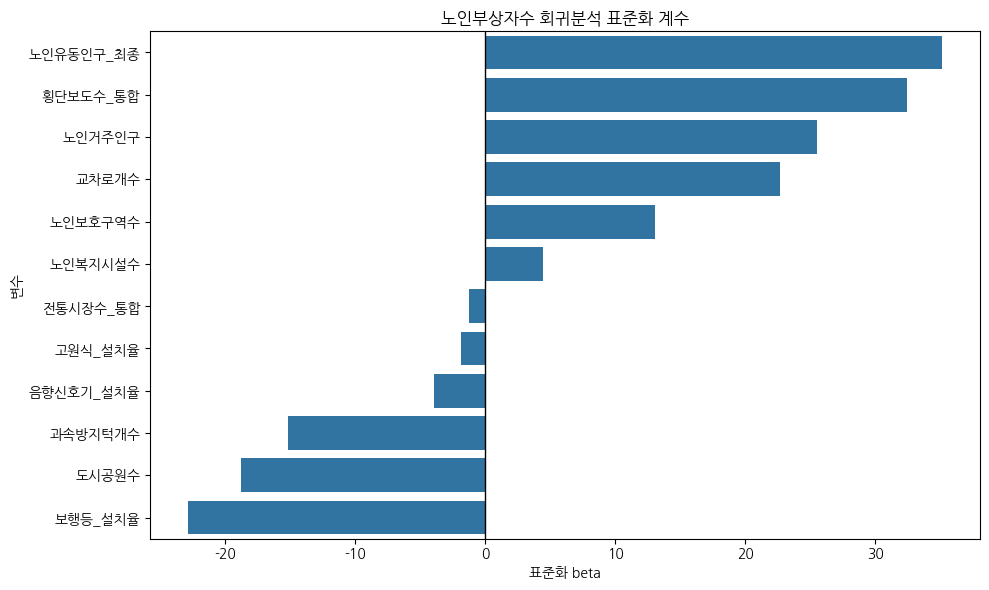

In [ ]:
# 회귀계수 시각화

plt.figure(figsize=(10, 6))
sns.barplot(
    data=coef_df,
    x="표준화_beta",
    y="변수"
)
plt.axvline(0, color="black", linewidth=1)
plt.title("노인부상자수 회귀분석 표준화 계수")
plt.xlabel("표준화 beta")
plt.ylabel("변수")
plt.tight_layout()
plt.show()

# beta 기반 가중치 만들기

In [ ]:
# 절댓값 beta 기준 중요도 계산

coef_weight = coef_df.copy()
coef_weight["abs_beta"] = coef_weight["표준화_beta"].abs()
coef_weight["전체_가중치"] = coef_weight["abs_beta"] / coef_weight["abs_beta"].sum()

coef_weight.sort_values("전체_가중치", ascending=False)

,변수,표준화_beta,abs_beta,전체_가중치
1,노인유동인구_최종,35.149720,35.149720,0.178476
3,횡단보도수_통합,32.411065,32.411065,0.164570
0,노인거주인구,25.554913,25.554913,0.129758
11,보행등_설치율,-22.844872,22.844872,0.115997
4,교차로개수,22.652827,22.652827,0.115022
6,도시공원수,-18.716558,18.716558,0.095035
8,과속방지턱개수,-15.104741,15.104741,0.076696
7,노인보호구역수,13.069236,13.069236,0.066360
2,노인복지시설수,4.446524,4.446524,0.022578
9,음향신호기_설치율,-3.910176,3.910176,0.019854


In [ ]:
# 그룹별 가중치 함수
# 사고위험, 보행충돌노출, 안전인프라 그룹별로 가중치를 따로 정규화함.

def make_group_weights(coef_df, group_vars):
    temp = coef_df[coef_df["변수"].isin(group_vars)].copy()
    temp["abs_beta"] = temp["표준화_beta"].abs()

    if temp["abs_beta"].sum() == 0:
        temp["가중치"] = 1 / len(temp)
    else:
        temp["가중치"] = temp["abs_beta"] / temp["abs_beta"].sum()

    return temp[["변수", "표준화_beta", "가중치"]].sort_values("가중치", ascending=False)

In [ ]:
# 변수 그룹 정의

risk_vars = [
    "노인거주인구",
    "노인유동인구_최종",
    "노인복지시설수"
]

collision_vars = [
    "횡단보도수_통합",
    "교차로개수",
    "전통시장수_통합",
    "도시공원수"
]

infra_vars = [
    "노인보호구역수",
    "과속방지턱개수",
    "음향신호기_설치율",
    "고원식_설치율",
    "보행등_설치율"
]

risk_vars = [v for v in risk_vars if v in reg_features]
collision_vars = [v for v in collision_vars if v in reg_features]
infra_vars = [v for v in infra_vars if v in reg_features]

In [ ]:
# 그룹별 가중치 확인

risk_weights = make_group_weights(coef_df, risk_vars)
collision_weights = make_group_weights(coef_df, collision_vars)
infra_weights = make_group_weights(coef_df, infra_vars)

print("사고위험 가중치")
display(risk_weights)

print("보행충돌노출 가중치")
display(collision_weights)

print("안전인프라 가중치")
display(infra_weights)

사고위험 가중치


,변수,표준화_beta,가중치
1,노인유동인구_최종,35.149720,0.539510
0,노인거주인구,25.554913,0.392240
2,노인복지시설수,4.446524,0.068249


보행충돌노출 가중치


,변수,표준화_beta,가중치
3,횡단보도수_통합,32.411065,0.432038
4,교차로개수,22.652827,0.301961
6,도시공원수,-18.716558,0.249491
5,전통시장수_통합,-1.238541,0.016510


안전인프라 가중치


,변수,표준화_beta,가중치
11,보행등_설치율,-22.844872,0.402387
8,과속방지턱개수,-15.104741,0.266053
7,노인보호구역수,13.069236,0.230200
9,음향신호기_설치율,-3.910176,0.068873
10,고원식_설치율,-1.844388,0.032487


# beta 기반 점수 재계산

In [ ]:
# 점수 계산용 MinMax 스케일링

score_vars = list(set(risk_vars + collision_vars + infra_vars + ["사고발생건수"]))

scaler_score = MinMaxScaler()

analysis_df[[v + "_scaled" for v in score_vars]] = scaler_score.fit_transform(
    analysis_df[score_vars]
)

In [ ]:
# 가중합 점수 함수

def weighted_score(df, weight_df):
    score = 0
    for _, row in weight_df.iterrows():
        var = row["변수"]
        w = row["가중치"]
        score += w * df[var + "_scaled"]
    return score

In [ ]:
# beta 기반 사고위험점수
# 정책 우선순위에는 과거 사고 이력도 중요하므로, 사고발생건수는 별도로 40% 반영하고,
# 나머지 60%를 beta 기반 위험요인으로 반영.

analysis_df["사고위험요인점수_beta"] = weighted_score(analysis_df, risk_weights)

analysis_df["사고위험점수_beta"] = (
    0.40 * analysis_df["사고발생건수_scaled"] +
    0.60 * analysis_df["사고위험요인점수_beta"]
)

In [ ]:
# beta 기반 보행충돌노출점수

analysis_df["보행충돌노출점수_beta"] = weighted_score(analysis_df, collision_weights)

In [ ]:
# beta 기반 안전인프라점수
# 안전시설 설치율은 높을수록 안전관리 수준이 높다고 보고, 그대로 안전인프라점수에 넣으면 됨.

analysis_df["안전인프라점수_beta"] = weighted_score(analysis_df, infra_weights)

In [ ]:
# 최종 사각지대점수 beta

analysis_df["사각지대점수_beta"] = (
    analysis_df["사고위험점수_beta"] +
    analysis_df["보행충돌노출점수_beta"]
) / (analysis_df["안전인프라점수_beta"] + 0.1)

In [ ]:
# 최종 개선우선순위

analysis_df["최종개선우선순위"] = analysis_df["사각지대점수_beta"].rank(
    ascending=False,
    method="dense"
).astype(int)

final_priority = analysis_df.sort_values("최종개선우선순위")

In [ ]:
# 최종 결과표

final_cols = [
    "최종개선우선순위",
    "자치구",
    "사고발생건수",
    "노인부상자수",
    "노인거주인구",
    "노인유동인구_최종",
    "노인복지시설수",
    "횡단보도수_통합",
    "교차로개수",
    "전통시장수_통합",
    "도시공원수",
    "노인보호구역수",
    "과속방지턱개수",
    "음향신호기_설치율",
    "고원식_설치율",
    "보행등_설치율",
    "사고위험점수_beta",
    "보행충돌노출점수_beta",
    "안전인프라점수_beta",
    "사각지대점수_beta"
]

final_cols = [col for col in final_cols if col in final_priority.columns]

final_priority[final_cols].head(10)

,최종개선우선순위,자치구,사고발생건수,노인부상자수,노인거주인구,노인유동인구_최종,노인복지시설수,횡단보도수_통합,교차로개수,전통시장수_통합,도시공원수,노인보호구역수,과속방지턱개수,음향신호기_설치율,고원식_설치율,보행등_설치율,사고위험점수_beta,보행충돌노출점수_beta,안전인프라점수_beta,사각지대점수_beta
0,1,강남구,270,494,96850.0,96143.071414,11,2745.0,488.0,10,100,13,890.0,0.248087,0.042623,0.287796,0.693991,0.880909,0.405946,3.112784
2,2,강북구,271,220,75413.0,54575.248701,32,1313.0,0.0,23,53,2,0.0,0.234577,0.067022,0.281797,0.471679,0.132634,0.162049,2.306107
16,3,성북구,275,290,88669.0,62666.033988,24,1859.0,336.0,14,83,8,788.0,0.238838,0.111350,0.293168,0.539694,0.534298,0.366196,2.303733
24,4,중랑구,305,305,89759.0,59204.824182,48,1661.0,306.0,22,72,3,743.0,0.278146,0.009031,0.318483,0.583877,0.443676,0.349775,2.284593
19,5,영등포구,253,356,74518.0,65983.465207,19,2361.0,459.0,23,57,4,778.0,0.293520,0.004659,0.345616,0.487723,0.665965,0.426864,2.189724
6,6,구로구,261,294,89539.0,58627.140714,15,1810.0,353.0,15,71,3,1010.0,0.275138,0.032597,0.324862,0.498871,0.502067,0.403342,1.988583
3,7,강서구,275,302,115304.0,79835.756415,31,2179.0,451.0,15,126,12,682.0,0.363469,0.007343,0.400642,0.689348,0.789276,0.643737,1.988100
23,8,중구,171,188,27996.0,41566.583306,3,1502.0,204.0,46,36,8,403.0,0.205060,0.028628,0.218375,0.146146,0.263492,0.122371,1.842136
10,9,동대문구,417,360,74076.0,59316.219736,23,1479.0,291.0,28,47,9,537.0,0.282623,0.102772,0.331981,0.664239,0.329245,0.441189,1.835744
8,10,노원구,243,284,106236.0,81156.451796,24,1706.0,391.0,9,134,7,896.0,0.318875,0.032239,0.398593,0.627003,0.656733,0.602735,1.826771


# 행정동 후보지 분석

In [ ]:
# 상위 10개 자치구 안에서 행정동으로 구체화 -> 행정동 단위 사고 데이터가 없으면
# 실제 사고를 예측보다는 행정동 후보지 추천이라고 표현하는 게 나을 것 같아서
# 자치구 단위 사각지대 상위 10개 지역 내부에서, 횡단보도·전통시장·안전시설 부족도를 기준으로 행정동 후보지를 세분화함.

In [ ]:
# 상위 10개 자치구 추출

top10_gu = final_priority.head(10)["자치구"].tolist()
top10_gu

['강남구', '강북구', '성북구', '중랑구', '영등포구', '구로구', '강서구', '중구', '동대문구', '노원구']

In [ ]:
import re
import pandas as pd
import numpy as np

# =====================
# 1. 횡단보도 행정동 데이터 생성
# =====================
cross_path = "/content/drive/MyDrive/노인 보행자 사고 데이터셋/서울시 자치구 횡단보도 정보 (1).csv"

try:
    df_cross = pd.read_csv(cross_path, encoding="cp949")
except:
    df_cross = pd.read_csv(cross_path, encoding="utf-8-sig")

def extract_dong_cross(addr):
    if pd.isna(addr):
        return None

    addr = str(addr).strip()

    m = re.match(r'(\S+구)\s+(\S+[동가리](?:\d+가)?)', addr)
    if m:
        return m.group(1) + ' ' + m.group(2)

    m2 = re.match(r'(\S+구)\s+(\S+)', addr)
    if m2:
        return m2.group(1) + ' ' + m2.group(2)

    return None

addr_col_cross = "소재지지번주소"
if addr_col_cross not in df_cross.columns:
    addr_candidates = [col for col in df_cross.columns if "주소" in col or "소재" in col]
    print("횡단보도 주소 후보:", addr_candidates)
    addr_col_cross = addr_candidates[0]

df_cross["행정동"] = df_cross[addr_col_cross].apply(extract_dong_cross)

df_cross["고원식"] = (df_cross["고원식횡단보도유무"] == "Y").astype(int)
df_cross["음향신호기"] = (df_cross["음향신호기설치여부"] == "Y").astype(int)
df_cross["보행등"] = (df_cross["보행등유무"] == "Y").astype(int)

count_col = "연번" if "연번" in df_cross.columns else "행정동"

cross_dong = (
    df_cross
    .dropna(subset=["행정동"])
    .groupby("행정동")
    .agg(
        횡단보도수=(count_col, "count"),
        고원식횡단보도개수=("고원식", "sum"),
        음향신호기개수=("음향신호기", "sum"),
        보행등개수=("보행등", "sum")
    )
    .reset_index()
)

cross_dong["고원식_설치율"] = cross_dong["고원식횡단보도개수"] / cross_dong["횡단보도수"]
cross_dong["음향신호기_설치율"] = cross_dong["음향신호기개수"] / cross_dong["횡단보도수"]
cross_dong["보행등_설치율"] = cross_dong["보행등개수"] / cross_dong["횡단보도수"]

print("cross_dong 생성 완료:", cross_dong.shape)


# =====================
# 2. 전통시장 행정동 데이터 생성
# =====================
mkt_path = "/content/drive/MyDrive/노인 보행자 사고 데이터셋/서울시 전통시장 현황(2025.7.31.기준).xlsx"

df_mkt = pd.read_excel(mkt_path)
df_mkt.columns = df_mkt.columns.str.strip()

df_mkt = df_mkt.rename(columns={
    "자치구 ": "자치구",
    "시장명 ": "시장명"
})

df_mkt = df_mkt[~df_mkt["연번"].astype(str).isin(["총계", "소계", "nan"])].copy()

if "시장명" in df_mkt.columns:
    df_mkt = df_mkt[~df_mkt["시장명"].astype(str).str.contains("지하도상점가|지하쇼핑", na=False)].copy()

df_mkt["점포수"] = pd.to_numeric(df_mkt["점포수"], errors="coerce").fillna(0)

def extract_dong_mkt(addr, gu=None):
    if pd.isna(addr) or str(addr).strip() in ["0", ""]:
        return None

    addr = str(addr).strip()
    addr = re.sub(r"^서울특별시\s+", "", addr)
    addr = re.sub(r"^서울시\s+", "", addr)
    addr = re.sub(r"^서울\s+", "", addr)

    m = re.search(r"(\S+구)\s+(\S*(?:동\d*가?|\d+가))", addr)
    if m:
        return m.group(1) + " " + m.group(2)

    m2 = re.search(r"(\S+구)\s+(\S+[동가])", addr)
    if m2:
        return m2.group(1) + " " + m2.group(2)

    m3 = re.search(r"^(\S*(?:동\d*가?|\d+가))", addr)
    if m3 and gu:
        return str(gu).strip() + " " + m3.group(1)

    m4 = re.search(r"^(\S+[동가])", addr)
    if m4 and gu:
        return str(gu).strip() + " " + m4.group(1)

    return None

addr_col_mkt = "구주소(번지주소)"
if addr_col_mkt not in df_mkt.columns:
    addr_candidates = [col for col in df_mkt.columns if "주소" in col]
    print("전통시장 주소 후보:", addr_candidates)
    addr_col_mkt = addr_candidates[0]

df_mkt["행정동"] = df_mkt.apply(
    lambda r: extract_dong_mkt(r[addr_col_mkt], r["자치구"]),
    axis=1
)

mkt_dong = (
    df_mkt
    .dropna(subset=["행정동"])
    .groupby("행정동")
    .agg(
        시장수=("시장명", "count"),
        총점포수=("점포수", "sum")
    )
    .reset_index()
)

print("mkt_dong 생성 완료:", mkt_dong.shape)

cross_dong 생성 완료: (457, 8)
mkt_dong 생성 완료: (184, 3)


In [ ]:
dong_df = cross_dong.merge(
    mkt_dong,
    on="행정동",
    how="left"
)

dong_df = dong_df.fillna(0)

# 행정동에서 자치구 추출
dong_df["자치구"] = dong_df["행정동"].astype(str).str.extract(r"^(\S+구)")

dong_df = dong_df[dong_df["자치구"].isin(top10_gu)].copy()

dong_df.head()

,행정동,횡단보도수,고원식횡단보도개수,음향신호기개수,보행등개수,고원식_설치율,음향신호기_설치율,보행등_설치율,시장수,총점포수,자치구
0,강남구 개포동,148,24,83,86,0.162162,0.560811,0.581081,0.0,0.0,강남구
1,강남구 논현동,286,3,41,48,0.010490,0.143357,0.167832,2.0,180.0,강남구
2,강남구 대치동,372,11,90,95,0.029570,0.241935,0.255376,1.0,549.0,강남구
3,강남구 도곡동,169,5,31,45,0.029586,0.183432,0.266272,0.0,0.0,강남구
4,강남구 삼성동,311,6,68,75,0.019293,0.218650,0.241158,0.0,0.0,강남구


In [ ]:
# 행정동 안전시설 부족도 생성

dong_df["음향신호기_부족도"] = 1 - dong_df["음향신호기_설치율"]
dong_df["고원식_부족도"] = 1 - dong_df["고원식_설치율"]
dong_df["보행등_부족도"] = 1 - dong_df["보행등_설치율"]

In [ ]:
# 행정동 점수 계산
# 행정동 단위에서는 사고 데이터가 없으므로, 보행 접점 + 목적지 + 안전시설 부족도 중심으로 점수를 만들었음.

dong_score_cols = [
    "횡단보도수",
    "시장수",
    "총점포수",
    "음향신호기_부족도",
    "고원식_부족도",
    "보행등_부족도"
]

dong_score_cols = [col for col in dong_score_cols if col in dong_df.columns]

scaler_dong = MinMaxScaler()

dong_df[[col + "_scaled" for col in dong_score_cols]] = scaler_dong.fit_transform(
    dong_df[dong_score_cols]
)

In [ ]:
# 행정동 후보지 점수

dong_df["행정동_개선후보점수"] = (
    0.35 * dong_df["횡단보도수_scaled"] +
    0.20 * dong_df["시장수_scaled"] +
    0.15 * dong_df["총점포수_scaled"] +
    0.10 * dong_df["음향신호기_부족도_scaled"] +
    0.10 * dong_df["고원식_부족도_scaled"] +
    0.10 * dong_df["보행등_부족도_scaled"]
)

dong_priority = dong_df.sort_values(
    ["자치구", "행정동_개선후보점수"],
    ascending=[True, False]
)

In [ ]:
# 자치구별 행정동 TOP 3 후보

dong_top3_by_gu = (
    dong_priority
    .groupby("자치구")
    .head(3)
    [
        [
            "자치구",
            "행정동",
            "횡단보도수",
            "시장수",
            "총점포수",
            "음향신호기_설치율",
            "고원식_설치율",
            "보행등_설치율",
            "행정동_개선후보점수"
        ]
    ]
)

dong_top3_by_gu

,자치구,행정동,횡단보도수,시장수,총점포수,음향신호기_설치율,고원식_설치율,보행등_설치율,행정동_개선후보점수
9,강남구,강남구 역삼동,369,2.0,246.0,0.241192,0.021680,0.271003,0.444755
2,강남구,강남구 대치동,372,1.0,549.0,0.241935,0.029570,0.255376,0.438470
1,강남구,강남구 논현동,286,2.0,180.0,0.143357,0.010490,0.167832,0.431070
26,강북구,강북구 수유동,459,12.0,839.0,0.209150,0.091503,0.241830,0.623977
24,강북구,강북구 미아동,557,8.0,494.0,0.222621,0.048474,0.281867,0.618944
25,강북구,강북구 번동,236,2.0,134.0,0.313559,0.063559,0.360169,0.341611
38,강서구,강서구 화곡동,430,5.0,535.0,0.288372,0.000000,0.374419,0.507280
32,강서구,강서구 등촌동,316,2.0,130.0,0.335443,0.006329,0.357595,0.395674
34,강서구,강서구 방화동,327,1.0,91.0,0.428135,0.000000,0.464832,0.362317
54,구로구,구로구 구로동,650,2.0,340.0,0.287692,0.032308,0.327692,0.573187


# 결과 시각화

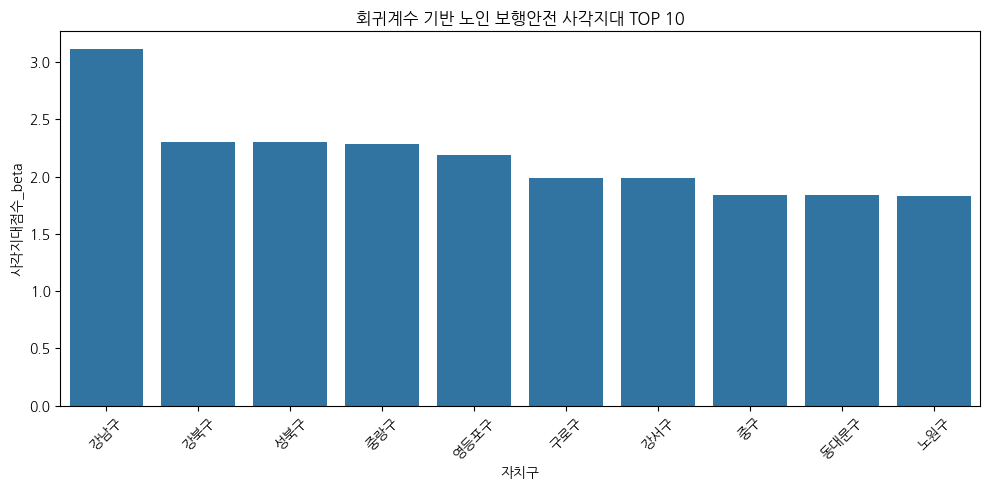

In [ ]:
# 자치구 최종 개선우선순위 TOP 10

top10_final = final_priority.head(10)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=top10_final,
    x="자치구",
    y="사각지대점수_beta"
)
plt.title("회귀계수 기반 노인 보행안전 사각지대 TOP 10")
plt.xlabel("자치구")
plt.ylabel("사각지대점수_beta")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

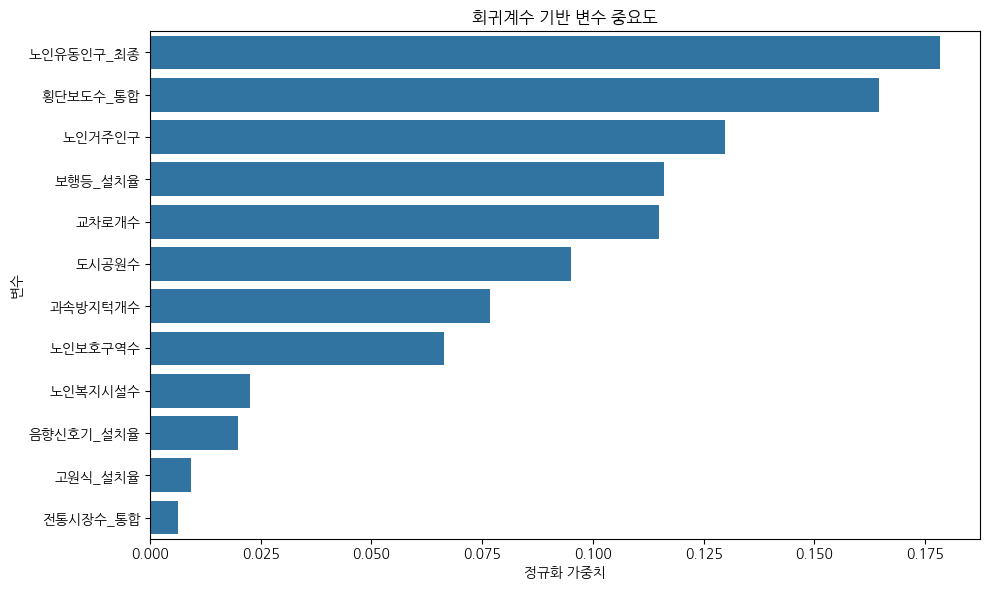

In [ ]:
# 회귀계수 기반 변수 중요도

plt.figure(figsize=(10, 6))
sns.barplot(
    data=coef_weight.sort_values("전체_가중치", ascending=False),
    x="전체_가중치",
    y="변수"
)
plt.title("회귀계수 기반 변수 중요도")
plt.xlabel("정규화 가중치")
plt.ylabel("변수")
plt.tight_layout()
plt.show()

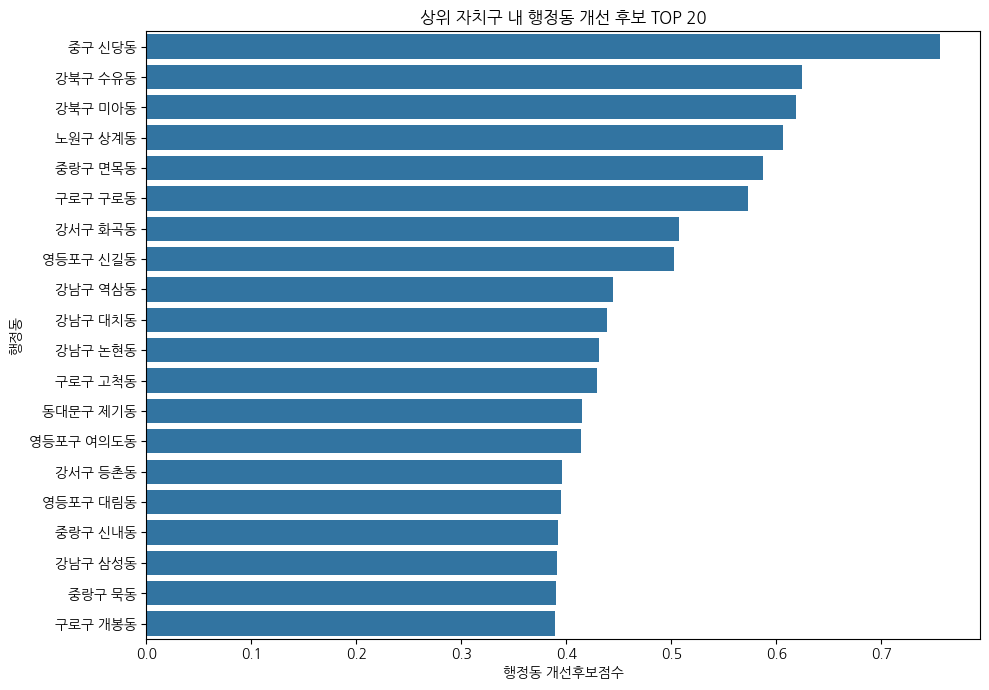

In [ ]:
# 행정동 후보 TOP 20

dong_top20 = dong_df.sort_values(
    "행정동_개선후보점수",
    ascending=False
).head(20)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=dong_top20,
    x="행정동_개선후보점수",
    y="행정동"
)
plt.title("상위 자치구 내 행정동 개선 후보 TOP 20")
plt.xlabel("행정동 개선후보점수")
plt.ylabel("행정동")
plt.tight_layout()
plt.show()

In [ ]:
eda_new.to_csv("eda_new_최종데이터.csv", index=False, encoding="utf-8-sig")

In [ ]:
from google.colab import files

eda_new.to_csv("eda_new_최종데이터.csv", index=False, encoding="utf-8-sig")
files.download("eda_new_최종데이터.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>